# Seleção de Meta-Features com Algoritmos Genéticos em Meta-Learning

Pipeline completo de meta-aprendizado para recomendação de algoritmos de classificação
usando datasets reais do OpenML.

### Visão geral do pipeline

```
OpenML (500 datasets)
        │
        ▼
[Fase 1] Avaliação dos base learners → meta_y (melhor algoritmo por dataset)
        │
        ▼
[Fase 2] Extração de meta-features com pymfe → meta_X (matriz de descrição)
        │
        ▼
[Fase 3] Pré-processamento: imputação → variância → correlação (MI pré-filtro) → escala
        │
        ▼
[Fase 4] GA com cromossomo expandido:
         ├─ Seleciona subconjunto de meta-features
         ├─ Seleciona qual meta-modelo usar (RF / SVM / KNN / MLP)
         ├─ Otimiza hiperparâmetros do meta-modelo escolhido
         ├─ Otimiza estratégia de pré-processamento (imputer / scaler)
         └─ Inicialização MI-seeded + fitness com accuracy alinhada
        │
        ▼
[Fase 5] StratifiedKFold 8-fold compara GA-expandido vs Baseline vs Random vs Feature Importance
        │
        ▼
[Fase 6] Ensemble Pareto: melhores soluções de cada fold formam ensemble votado
```

### Melhorias v2 (base de comparação)

| Componente | Mudança | Motivo |
|---|---|---|
| `OUTER_CV` | `KFold` → `StratifiedKFold` | Meta-dataset desbalanceado |
| `META_MODEL` | `max_depth=None` → `max_depth=15, leaf=2, balanced` | Evita overfitting |
| `GradientBoosting` | → `HistGradientBoosting` | 5–10× mais rápido |
| `fit_meta_preprocessor` | + filtro de correlação `|r|>0.90` | Reduz espaço GA ~148→~90 |
| **GA caching** | `dict` por hash da máscara | Evita recalcular fitness repetido |
| **GA penalidade** | fixa 0.03 → dinâmica escalonada | Pune quadraticamente soluções acima de 30% |
| `crossover_type` | `single_point` → `two_points` | Preserva blocos cooperantes |
| Histórico GA | fold 1 → todos os folds | Diagnóstico completo de convergência |

### Melhorias v4 (vs v2)

| # | Componente | v2 | v4 | Motivo |
|---|---|---|---|---|
| 1 | **Cromossomo expandido** | só features | features + modelo + hiperparâmetros | GA otimiza tudo junto; interações features↔hiperparâmetros capturadas |
| 2 | **Seleção de meta-modelo** | fixo `RandomForest` | GA escolhe entre RF / SVM-RBF / KNN / MLP | Meta-modelo ótimo pode variar por fold |
| 3 | **Pré-processamento evoluído** | fixo (median+StandardScaler) | GA escolhe imputer (median/mean/knn) + scaler (Standard/MinMax/Robust) | Combinação ótima depende da distribuição das meta-features no fold |
| 4 | **OUTER_CV** | 5 folds | **8 folds** | Cada fold treina com 87.5% dos dados; estimativas mais estáveis |
| 5 | **Inicialização MI-seeded** | 35% aleatório | híbrido: 50% da pop recebe top-20% features por Mutual Information | Convergência mais rápida; evita gerações desperdiçadas |
| 6 | **Scoring do fitness** | `f1_macro` | `accuracy` | Alinha otimização com a métrica final; elimina descolamento observado nos dados |
| 7 | **Ensemble Pareto pós-GA** | único modelo por fold | melhores soluções de todos os folds formam ensemble votado | Aproveita diversidade entre folds; tende a superar a melhor solução individual |
| 8 | **GA_PENALTY_THRESHOLD** | 0.30 | **0.40** | Mais espaço de exploração antes da penalidade quadrática |
| 9 | **keep_elitism** | 2 | **3** | Preserva um pouco mais de boas soluções entre gerações |
| 10 | **stop_criteria** | `saturate_8` | **`saturate_12`** | Não para cedo demais; aguarda estagnação real |

> **Checkpointing:** cada etapa salva artefatos em disco. Execuções seguintes carregam
> do cache, pulando o processamento já concluído.


## 0. Instalação de dependências

In [ ]:
# Execute apenas na primeira vez ou ao atualizar o ambiente.
!pip install -U openml pandas scikit-learn joblib seaborn matplotlib pymfe pygad -q

## 1. Imports e configuração global

In [11]:
# ── Biblioteca padrão ──────────────────────────────────────────────────────
import os           # variáveis de ambiente e contagem de CPUs
import re           # expressões regulares para normalização de nomes
import json         # serialização legível de objetos simples
import random       # semente global de aleatoriedade
import pickle       # serialização binária de objetos Python complexos
import warnings     # supressão de avisos irrelevantes
from pathlib import Path           # manipulação portável de caminhos
from collections import Counter    # contagem de frequência das meta-features selecionadas
from dataclasses import dataclass  # estrutura de dados sem boilerplate
from typing import Dict, List, Optional, Tuple

# ── Computação numérica e dados ────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualização ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── OpenML, meta-features e GA ─────────────────────────────────────────────
import openml
import pygad
from pymfe.mfe import MFE

# ── Scikit-learn ───────────────────────────────────────────────────────────
from joblib import Parallel, delayed
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    HistGradientBoostingClassifier,  # substitui GradientBoostingClassifier
)
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.impute import SimpleImputer, KNNImputer  # KNNImputer usado no GA pré-proc evoluído
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder,
    StandardScaler, MinMaxScaler, RobustScaler,  # [v4] scalers candidatos no pré-proc evoluído
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier  # [v4] meta-modelo candidato no GA
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Semente única para todas as fontes de aleatoriedade do experimento.
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

TARGET_DATASETS   = 500
OPENML_SAMPLE_CAP = 650

# N_JOBS: paralelismo externo por dataset; internamente cada modelo usa n_jobs=1
# para evitar oversubscription (mais threads que CPUs físicos).
N_JOBS = max(1, (os.cpu_count() or 2) - 1)

# ── Diretórios de artefatos ────────────────────────────────────────────────
PROJECT_ROOT            = Path.cwd()
CACHE_DIR               = PROJECT_ROOT / "artifacts_meta_learning"
DATASETS_DIR            = CACHE_DIR / "datasets"
META_DIR                = CACHE_DIR / "meta"
RESULTS_DIR             = CACHE_DIR / "results"
INTERMEDIATE_TABLES_DIR = PROJECT_ROOT / "intermidiate_tables_csv"

for folder in [CACHE_DIR, DATASETS_DIR, META_DIR, RESULTS_DIR, INTERMEDIATE_TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MPL_TMP = os.path.join(os.getcwd(), ".mplconfig")
os.makedirs(MPL_TMP, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", MPL_TMP)

print(f"N_JOBS configurado para: {N_JOBS}")
print(f"Cache local: {CACHE_DIR}")


N_JOBS configurado para: 7
Cache local: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning


## 2. Configurações experimentais

In [12]:
# ── Algoritmos do nível-base ───────────────────────────────────────────────
# Cada algoritmo é avaliado em todos os 500 datasets via cross-validation.
# O algoritmo com maior acurácia média vira a meta-label daquele dataset.
#
# MELHORIAS v2:
#   • HistGradientBoostingClassifier substitui GradientBoostingClassifier.
#   • ExtraTrees reduzido de 250 para 100 estimadores.
BASE_MODELS = {
    "DecisionTree":         DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVC":                  SVC(gamma="scale", random_state=RANDOM_STATE),
    "KNN":                  KNeighborsClassifier(),
    "LogisticRegression":   LogisticRegression(
                                max_iter=1500, solver="lbfgs",
                                random_state=RANDOM_STATE),
    "ExtraTrees":           ExtraTreesClassifier(
                                n_estimators=100,
                                random_state=RANDOM_STATE,
                                n_jobs=1),
    "HistGradientBoosting": HistGradientBoostingClassifier(
                                random_state=RANDOM_STATE),
    "GaussianNB":           GaussianNB(),
}

# ── Meta-modelo completo — avaliação final ─────────────────────────────────
# Usado em evaluate_meta_strategy e baselines. 300 árvores para máxima
# qualidade nos resultados reportados. Este é o "Baseline" do paper.
META_MODEL = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# ── Meta-modelo leve — usado APENAS dentro do fitness do GA ───────────────
# Compara máscaras entre si, não maximiza acurácia absoluta.
# 100 árvores e 3 folds reduzem o tempo do GA em ~60% sem impacto final.
GA_INTERNAL_MODEL = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# ── [v4] Candidatos de meta-modelo para o cromossomo expandido ────────────
# O GA agora escolhe QUAL meta-modelo usar além de QUAIS features selecionar.
# Cada candidato é instanciado de forma leve para caber no fitness (3 folds).
#
# gene_modelo (int 0–3) → modelo correspondente:
#   0 = RandomForest  — padrão v2; bom em geral; robusto a escala
#   1 = SVM-RBF       — eficaz com poucos datasets (~400 treino); sensível à escala
#   2 = KNN           — simples; pode capturar vizinhanças locais de meta-features
#   3 = MLP           — não-linear; pode capturar interações complexas entre meta-features
#
# IMPORTANTE: todos usam n_jobs=1 para evitar oversubscription com o GA paralelo.
GA_CANDIDATE_MODELS = [
    RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=2,
                           class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
    SVC(kernel="rbf", gamma="scale", class_weight="balanced",
        random_state=RANDOM_STATE, probability=False),
    KNeighborsClassifier(n_neighbors=5, n_jobs=1),
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                  random_state=RANDOM_STATE, early_stopping=True),
]
GA_CANDIDATE_MODEL_NAMES = ["RandomForest", "SVM-RBF", "KNN", "MLP"]

# ── [v4] Candidatos de pré-processamento para o cromossomo expandido ──────
# O GA escolhe a combinação de imputador + scaler a aplicar nas meta-features.
# A combinação ótima pode variar dependendo da distribuição do fold.
#
# gene_imputer (int 0–2):
#   0 = median  (padrão v2; robusto a outliers)
#   1 = mean    (adequado quando distribuição é aproximadamente normal)
#   2 = knn     (preserva estrutura local; mais lento mas mais preciso)
#
# gene_scaler (int 0–2):
#   0 = StandardScaler  (padrão v2; centraliza em 0, desvio 1)
#   1 = MinMaxScaler    (mapeia para [0,1]; bom quando há limites naturais)
#   2 = RobustScaler    (usa mediana/IQR; robusto a outliers extremos)
GA_CANDIDATE_IMPUTERS = ["median", "mean", "knn"]
GA_CANDIDATE_SCALERS  = [StandardScaler, MinMaxScaler, RobustScaler]
GA_CANDIDATE_SCALER_NAMES = ["StandardScaler", "MinMaxScaler", "RobustScaler"]

# ── Esquemas de cross-validation ──────────────────────────────────────────
# OUTER_CV: [v4] 8 folds (era 5). Treino usa 87.5% dos 500 datasets por fold,
# gerando estimativas mais estáveis e reduzindo variância entre folds.
OUTER_CV = StratifiedKFold(n_splits=8, shuffle=True, random_state=RANDOM_STATE)

# INNER_META_CV: 3 folds dentro do fitness do GA — balanceia sinal e velocidade.
# Aumentar para 5 melhora o sinal mas ~1.7× mais lento por fold do GA.
INNER_META_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# BASE_CV: avalia cada base learner em cada dataset do OpenML.
BASE_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Configuração do Algoritmo Genético ────────────────────────────────────
# O cromossomo v4 tem estrutura: [features... | gene_modelo | gene_imputer | gene_scaler]
# Os últimos 3 genes são inteiros (0–N) e tratados separadamente no fitness.
GA_CONFIG = {
    "num_generations":       40,    # [v4] era 30; mais orçamento sem explodir o tempo
    "sol_per_pop":           30,    # mantido; população de 30 indivíduos
    "num_parents_mating":    10,
    "parent_selection_type": "sss",
    "keep_elitism":          3,     # [v4] era 2; preserva um pouco mais das melhores soluções
    "crossover_type":        "two_points",
    "mutation_type":         "adaptive",
    "mutation_probability":  [0.25, 0.05],
    "gene_space":            None,  # definido dinamicamente em run_ga_feature_selection
    "suppress_warnings":     True,
    "stop_criteria":         ["saturate_12"],  # [v4] era saturate_8; evita parada prematura
}

# ── Penalidade dinâmica do fitness do GA ──────────────────────────────────
GA_PENALTY_ALPHA     = 0.08
GA_PENALTY_THRESHOLD = 0.40  # [v4] era 0.30; mais espaço de exploração sem penalidade quadrática

META_FEATURE_GROUPS   = ["general", "statistical", "info-theory", "landmarking"]
CORRELATION_THRESHOLD = 0.90


## 3. Utilitários de cache em disco

Cada etapa pesada persiste seus artefatos como arquivos `.pkl`. Nas execuções
seguintes o notebook detecta os arquivos e pula o processamento já concluído.


In [22]:
def save_pickle(obj, path: Path) -> None:
    """Persiste qualquer objeto Python em formato binário (pickle)."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as f:
        pickle.dump(obj, f)

def load_pickle(path: Path):
    """Carrega um objeto previamente serializado com save_pickle."""
    with path.open("rb") as f:
        return pickle.load(f)

def save_json(obj, path: Path) -> None:
    """Persiste listas/dicionários simples em JSON legível por humanos."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def load_json(path: Path):
    """Carrega um objeto previamente salvo com save_json."""
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Persiste um DataFrame preservando índices, dtypes e metadados."""
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_pickle(path)

def load_dataframe(path: Path) -> pd.DataFrame:
    """Carrega um DataFrame previamente salvo com save_dataframe."""
    return pd.read_pickle(path)

# ── Caminhos dos artefatos (numerados para rastreabilidade) ────────────────
CATALOG_PATH              = CACHE_DIR / "01_openml_catalog_filtered_and_deduplicated.pkl"
DATASETS_PATH             = DATASETS_DIR / "02_real_openml_datasets_downloaded_and_validated.pkl"
BASE_RESULTS_PATH         = META_DIR / "03_base_level_model_evaluation_results.pkl"
BASE_RESULTS_DF_PATH      = META_DIR / "03_base_level_model_evaluation_results_dataframe.pkl"
META_Y_PATH               = META_DIR / "04_meta_labels_best_base_learner_per_dataset.pkl"
META_X_PATH               = META_DIR / "05_meta_features_matrix_extracted_with_pymfe.pkl"
OUTER_RESULTS_PATH        = RESULTS_DIR / "06_outer_cv_ga_feature_selection_evaluation_results.pkl"
TOP_FEATURES_COUNTER_PATH = RESULTS_DIR / "07_ga_selected_meta_feature_frequency_counter.pkl"
ALL_FOLDS_HISTORY_PATH    = RESULTS_DIR / "08_ga_convergence_history_all_folds.pkl"
# [v4] Novos artefatos para cromossomo expandido e ensemble Pareto
GA_CONFIG_LOG_PATH        = RESULTS_DIR / "09_ga_chosen_model_preproc_per_fold.pkl"
ENSEMBLE_PATH             = RESULTS_DIR / "10_pareto_ensemble_results.pkl"



## 4. Seleção de datasets no OpenML

Busca e filtra datasets de classificação que satisfaçam critérios controlados
de tamanho, dimensão e balanceamento de classes.


In [23]:
def normalize_name(name: object) -> str:
    """
    Normaliza o nome de um dataset para identificar duplicatas semânticas.

    Remove sufixos de versão ('_v2', '-v3'), substitui separadores por '_'
    e converte para minúsculas. Exemplos: 'Iris_v2' e 'iris-V3' → 'iris'.
    Usado para deduplicar o catálogo mantendo apenas a versão mais recente
    de cada dataset.
    """
    if pd.isna(name):
        return "unknown"
    name = str(name).lower()
    name = re.sub(r"[_\- ]v\d+", "", name)
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")


def build_openml_catalog(target_size: int, sample_cap: int, seed: int) -> pd.DataFrame:
    """
    Constrói um catálogo filtrado de datasets candidatos do OpenML.

    Filtros de qualidade aplicados:
      • 200 ≤ instâncias ≤ 10.000  — tamanho computacionalmente viável
      • 5 ≤ features ≤ 100         — complexidade moderada
      • 2 ≤ classes ≤ 10           — classificação multiclasse controlada
      • classe minoritária ≥ 20    — permite StratifiedKFold sem erros
      • exclui datasets FOREX      — séries temporais, incompatíveis com pymfe

    Deduplicação semântica: mantém apenas a versão mais recente de cada
    nome normalizado (evita múltiplas versões do mesmo problema no meta-dataset).

    MELHORIA em relação à versão anterior:
      A versão original ordenava o catálogo por tamanho (NumberOfInstances,
      NumberOfFeatures) antes de baixar. Isso fazia o pipeline processar
      sistematicamente os datasets MENORES primeiro, gerando meta-features
      instáveis (alta variância com poucos dados). Agora embaralhamos
      aleatoriamente, garantindo diversidade de tamanho entre os 500 datasets.
    """
    print("Carregando catálogo do OpenML...")
    df = openml.datasets.list_datasets(output_format="dataframe")

    required_cols = [
        "did", "name", "version",
        "NumberOfInstances", "NumberOfFeatures",
        "NumberOfClasses", "MinorityClassSize",
    ]
    df = df[required_cols].copy()

    df = df[
        df["NumberOfInstances"].between(200, 10000)
        & df["NumberOfFeatures"].between(5, 100)
        & df["NumberOfClasses"].between(2, 10)
        & (df["MinorityClassSize"] >= 20)
        & (~df["name"].str.contains("FOREX", case=False, na=False))
    ].copy()

    df["normalized_name"] = df["name"].apply(normalize_name)
    df = df.drop_duplicates(subset=["did"])
    df = df.sort_values("version", ascending=False).drop_duplicates(
        subset=["normalized_name"]
    )

    if len(df) > sample_cap:
        df = df.sample(n=sample_cap, random_state=seed)

    # Embaralha sem ordenar por tamanho — garante diversidade de datasets.
    return df.sample(frac=1, random_state=seed + 1).reset_index(drop=True)


if CATALOG_PATH.exists():
    catalog_df = load_dataframe(CATALOG_PATH)
    print(f"Catálogo carregado do cache: {CATALOG_PATH}")
else:
    catalog_df = build_openml_catalog(TARGET_DATASETS, OPENML_SAMPLE_CAP, RANDOM_STATE)
    save_dataframe(catalog_df, CATALOG_PATH)
    print(f"Catálogo salvo em: {CATALOG_PATH}")

print(f"Candidatos no catálogo: {len(catalog_df)}")
catalog_df.head()


Catálogo carregado do cache: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/01_openml_catalog_filtered_and_deduplicated.pkl
Candidatos no catálogo: 650


,did,name,version,NumberOfInstances,NumberOfFeatures,NumberOfClasses,MinorityClassSize,normalized_name
0,446,prnn_crabs,1,200.0,8.0,2.0,100.0,prnn_crabs
1,721,pwLinear,2,200.0,11.0,2.0,97.0,pwlinear
2,43786,Zombies-Apocalypse,1,200.0,13.0,2.0,79.0,zombies_apocalypse
3,46844,Predicting_Risk_Factors_of_Chronic_Kidney_Disease,2,200.0,29.0,2.0,72.0,predicting_risk_factors_of_chronic_kidney_disease
4,42172,regime_alimentaire,1,202.0,20.0,2.0,41.0,regime_alimentaire


## 5. Download e validação dos datasets

Cada dataset é baixado individualmente do OpenML, sanitizado e validado.
Datasets que falham em qualquer critério são descartados silenciosamente
para não interromper o pipeline.


In [24]:
def _coerce_target(y: object) -> pd.Series:
    """
    Normaliza o target para pd.Series unidimensional com índice resetado.

    O OpenML retorna targets como Series, DataFrame ou array dependendo
    do dataset. Esta função unifica todos os casos e rejeita targets
    multi-rótulo (múltiplas colunas), que este experimento não suporta.
    """
    if isinstance(y, pd.Series):
        return y.reset_index(drop=True)
    if isinstance(y, pd.DataFrame):
        if y.shape[1] != 1:
            raise ValueError("Target multirrótulo não suportado.")
        return y.iloc[:, 0].reset_index(drop=True)
    return pd.Series(y).reset_index(drop=True)


def _sanitize_dataframe(X: object) -> pd.DataFrame:
    """
    Padroniza o DataFrame de features com colunas nomeadas como strings.

    Alguns datasets retornam arrays numpy ou DataFrames com índices inteiros.
    Converter para strings garante compatibilidade com ColumnTransformer e pymfe.
    """
    df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    df.columns = [str(col) for col in df.columns]
    return df.reset_index(drop=True)


def download_openml_dataset(row: pd.Series) -> Optional[Dict]:
    """
    Baixa, valida e padroniza um único dataset do OpenML.

    Validações após o download (reconfirma após limpeza do target):
      • len(X) == len(y): consistência entre features e labels
      • 200 ≤ instâncias ≤ 10.000: tamanho ainda dentro do range
      • 5 ≤ features ≤ 100: dimensão dentro do range
      • 2 ≤ classes únicas ≤ 10: problema de classificação válido
      • classe minoritária ≥ 20: StratifiedKFold possível

    Retorna None em qualquer falha (download, conversão ou validação).
    """
    did = int(row["did"])
    try:
        dataset = openml.datasets.get_dataset(did, download_data=True)
        X, y, _, _ = dataset.get_data(
            dataset_format="dataframe",
            target=dataset.default_target_attribute,
        )
    except Exception as exc:
        print(f"[skip] did={did} | erro no download: {exc}")
        return None

    try:
        X = _sanitize_dataframe(X)
        y = _coerce_target(y)
    except Exception as exc:
        print(f"[skip] did={did} | erro na conversão: {exc}")
        return None

    if len(X) != len(y):
        return None
    if not (200 <= X.shape[0] <= 10000) or not (5 <= X.shape[1] <= 100):
        return None

    # Remove linhas com target inválido e revalida as condições de balanceamento.
    y = y.replace([np.inf, -np.inf], np.nan)
    valid_mask = y.notna()
    X = X.loc[valid_mask].reset_index(drop=True)
    y = y.loc[valid_mask].reset_index(drop=True)

    if y.nunique() < 2 or y.nunique() > 10:
        return None
    if y.value_counts().min() < 20:
        return None

    return {
        "openml_id": did,
        "name": f"openml_{did}_{normalize_name(row['name'])}",
        "data": X,
        "target": y,
    }


if DATASETS_PATH.exists():
    datasets = load_pickle(DATASETS_PATH)
    print(f"Datasets carregados do cache: {DATASETS_PATH}")
else:
    datasets = []
    for _, row in catalog_df.iterrows():
        ds = download_openml_dataset(row)
        if ds is not None:
            datasets.append(ds)
        if len(datasets) >= TARGET_DATASETS:
            break
    save_pickle(datasets, DATASETS_PATH)
    print(f"Datasets salvos em: {DATASETS_PATH}")

print(f"Datasets válidos: {len(datasets)}")
datasets[0]["data"].head() if datasets else None


Datasets carregados do cache: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/datasets/02_real_openml_datasets_downloaded_and_validated.pkl
Datasets válidos: 500


,sex,index,FL,RW,CL,CW,BD
0,Male,1,8.1,6.7,16.1,19.0,7.0
1,Male,2,8.8,7.7,18.1,20.8,7.4
2,Male,3,9.2,7.8,19.0,22.4,7.7
3,Male,4,9.6,7.9,20.1,23.1,8.2
4,Male,5,9.8,8.0,20.3,23.0,8.2


## 6. Funções auxiliares de pré-processamento

In [25]:
def infer_column_types(df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    """
    Identifica colunas categóricas e numéricas pelo dtype do pandas.

    Categóricas (precisam de encoding): object, category, bool.
    Numéricas (passam direto): float, int e derivados.
    """
    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()
    numeric_cols = [c for c in df.columns if c not in categorical_cols]
    return categorical_cols, numeric_cols


def encode_target(y: pd.Series) -> np.ndarray:
    """
    Codifica o target em inteiros contíguos [0, n_classes-1].

    Converter para str antes garante compatibilidade quando o OpenML
    retorna tipos mistos (int, float, str) na mesma coluna categórica.
    """
    return LabelEncoder().fit_transform(
        pd.Series(y).astype(str).reset_index(drop=True)
    )


def build_base_pipeline(model) -> Pipeline:
    """
    Constrói o pipeline de pré-processamento para avaliação dos base learners.

    MELHORIA: substituímos KNNImputer por SimpleImputer(median) nos numéricos.
    O KNNImputer é 10–100× mais lento e não altera o ranking dos algoritmos
    (não muda quem é o melhor), apenas adiciona custo sem benefício nesta etapa.

    Numéricos:    imputa pela mediana (robusto a outliers, muito mais rápido)
    Categóricos:  imputa pela moda + one-hot encoding
    Desconhecidas: descartadas (remainder='drop')
    """
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # era KNNImputer
    ])
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer,
             lambda X: X.select_dtypes(exclude=["object","category","bool"]).columns),
            ("cat", categorical_transformer,
             lambda X: X.select_dtypes(include=["object","category","bool"]).columns),
        ],
        remainder="drop",
    )
    return Pipeline([("preprocessor", preprocessor), ("model", model)])


def prepare_dataset_for_mfe(df: pd.DataFrame) -> np.ndarray:
    """
    Converte o dataset para matriz numérica densa compatível com o pymfe.

    O MFE exige numpy array sem NaN e sem colunas categóricas cruas.

    Processo:
      1. Categóricos: imputa pela moda → OrdinalEncoder
         (preserva estrutura ordinal para métricas de correlação do MFE)
      2. Numéricos: converte para float explicitamente
      3. KNNImputer (n_neighbors=5): preenche NaNs restantes via vizinhos próximos.
         Aqui KNNImputer É justificado — ao contrário do nível-base, a qualidade
         das meta-features depende de uma imputação mais rica: métricas como
         correlação e entropia são sensíveis à distribuição dos dados preenchidos.
    """
    categorical_cols, numeric_cols = infer_column_types(df)
    work_df = df.copy()

    if categorical_cols:
        work_df[categorical_cols] = SimpleImputer(
            strategy="most_frequent"
        ).fit_transform(work_df[categorical_cols])
        work_df[categorical_cols] = OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1
        ).fit_transform(work_df[categorical_cols])

    if numeric_cols:
        work_df[numeric_cols] = work_df[numeric_cols].apply(
            pd.to_numeric, errors="coerce"
        )

    return np.asarray(
        KNNImputer(n_neighbors=5).fit_transform(work_df), dtype=float
    )


## 7. Fase 1 — Geração das meta-labels (`meta_y`)

Avalia todos os base learners em cada dataset e registra o mais acurado.
Esse nome (ex: 'HistGradientBoosting') vira a meta-label do dataset.


In [26]:
def evaluate_base_learners(dataset: Dict) -> Dict:
    """
    Avalia todos os algoritmos candidatos em um dataset e retorna o melhor.

    Para cada algoritmo em BASE_MODELS:
      1. Constrói o pipeline com pré-processamento (build_base_pipeline)
      2. Executa cross_val_score com BASE_CV (StratifiedKFold 5-fold)
      3. Registra a acurácia média como score neste dataset

    O algoritmo com maior acurácia média vira a meta-label do dataset.

    n_jobs=1: o paralelismo externo (Parallel por dataset) já distribui
    a carga entre os CPUs. Usar n_jobs>1 internamente causaria
    oversubscription (mais threads que CPUs físicos), degradando performance.
    """
    X = dataset["data"]
    y = encode_target(dataset["target"])

    scores = {}
    for name, model in BASE_MODELS.items():
        cv_scores = cross_val_score(
            build_base_pipeline(clone(model)), X, y,
            cv=BASE_CV, scoring="accuracy", n_jobs=1,
        )
        scores[name] = float(np.mean(cv_scores))

    best = max(scores, key=scores.get)
    return {"dataset_name": dataset["name"], "best_model": best, "scores": scores}


if (BASE_RESULTS_PATH.exists()
        and BASE_RESULTS_DF_PATH.exists()
        and META_Y_PATH.exists()):
    print("Base-level results encontrados no cache, carregando...")
    base_results    = load_pickle(BASE_RESULTS_PATH)
    base_results_df = load_dataframe(BASE_RESULTS_DF_PATH)
    meta_y          = np.array(load_pickle(META_Y_PATH))
    print(f"Carregados de: {BASE_RESULTS_PATH}")
else:
    print("Avaliando base learners nos datasets (pode demorar)...")
    base_results = Parallel(n_jobs=N_JOBS, verbose=10)(
        delayed(evaluate_base_learners)(ds) for ds in datasets
    )
    meta_y = np.array([r["best_model"] for r in base_results])
    base_results_df = pd.DataFrame([
        {"dataset_name": r["dataset_name"], **r["scores"], "meta_label": r["best_model"]}
        for r in base_results
    ])
    save_pickle(base_results, BASE_RESULTS_PATH)
    save_dataframe(base_results_df, BASE_RESULTS_DF_PATH)
    save_pickle(meta_y.tolist(), META_Y_PATH)
    print(f"Resultados salvos em: {BASE_RESULTS_PATH}")

print("\nDistribuição das meta-labels:")
print(pd.Series(meta_y).value_counts())
base_results_df.head()


Base-level results encontrados no cache, carregando...
Carregados de: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/meta/03_base_level_model_evaluation_results.pkl

Distribuição das meta-labels:
HistGradientBoosting    202
ExtraTrees              135
LogisticRegression       80
SVC                      56
DecisionTree             20
GaussianNB                4
KNN                       3
Name: count, dtype: int64


,dataset_name,DecisionTree,SVC,KNN,LogisticRegression,ExtraTrees,HistGradientBoosting,GaussianNB,meta_label
0,openml_446_prnn_crabs,0.91500,0.83500,0.93000,0.995000,0.955000,0.935000,0.625000,LogisticRegression
1,openml_721_pwlinear,0.81000,0.88500,0.83000,0.845000,0.890000,0.900000,0.845000,HistGradientBoosting
2,openml_43786_zombies_apocalypse,0.69000,0.70000,0.67500,0.870000,0.825000,0.825000,0.820000,LogisticRegression
3,openml_46844_predicting_risk_factors_of_chroni...,1.00000,1.00000,0.96000,1.000000,1.000000,1.000000,1.000000,DecisionTree
4,openml_42172_regime_alimentaire,0.92061,0.94061,0.94061,0.980122,0.876098,0.955366,0.456585,LogisticRegression


## 8. Fase 2 — Extração das meta-features (`meta_X`)

O pymfe calcula métricas descritivas de cada dataset em 4 grupos.
Para métricas que retornam uma distribuição (ex: correlações de todos
os pares de atributos), calculamos 4 resumos: mean, sd, min, max —
multiplicando a riqueza descritiva do meta-dataset.


In [27]:
def extract_meta_features(dataset: Dict, groups: List[str]) -> Dict:
    """
    Extrai meta-features de um dataset usando o pymfe (MFE).

    Grupos e o que cada um captura:
      general:     estrutura básica — n_features, n_instances, n_classes,
                   razão instâncias/features, proporção de categóricos, etc.
      statistical: momentos estatísticos e correlações entre atributos
                   numéricos (média, variância, curtose, assimetria, etc.)
      info-theory: entropia das classes, informação mútua atributo-classe,
                   joint entropy — descrevem a estrutura de informação do dataset
      landmarking: acurácia de classificadores simples (1-NN, árvore rasa,
                   Naive Bayes) como proxies rápidas de complexidade do problema

    Resumos (mean, sd, min, max): meta-features que retornam uma distribuição
    de valores (ex: correlação de cada par de features) são sumarizadas em 4
    estatísticas, aumentando a representatividade sem perder informação.

    Retorna dicionário com nomes e valores das meta-features extraídas.
    """
    X_num = prepare_dataset_for_mfe(dataset["data"])
    y     = encode_target(dataset["target"])

    mfe = MFE(groups=groups, summary=["mean", "sd", "min", "max"])
    mfe.fit(X_num, y)
    names, values = mfe.extract()

    return {
        "dataset_name":   dataset["name"],
        "feature_names":  list(names),
        "feature_values": list(values),
    }


if META_X_PATH.exists():
    meta_X = load_dataframe(META_X_PATH)
    print(f"meta_X carregado do cache: {META_X_PATH}")
else:
    print("Extraindo meta-features dos datasets (pode demorar)...")
    meta_feature_results = Parallel(n_jobs=N_JOBS, verbose=10)(
        delayed(extract_meta_features)(ds, META_FEATURE_GROUPS) for ds in datasets
    )

    # Verifica que todos os datasets geraram o mesmo conjunto de meta-features.
    # Inconsistência indica versões diferentes do pymfe ou datasets problemáticos.
    reference_names = meta_feature_results[0]["feature_names"]
    for item in meta_feature_results[1:]:
        if item["feature_names"] != reference_names:
            raise ValueError(
                "A ordem ou quantidade de meta-features mudou entre datasets. "
                "Verifique se todos usam a mesma versão do pymfe."
            )

    meta_X = pd.DataFrame(
        [item["feature_values"] for item in meta_feature_results],
        columns=reference_names,
        index=[item["dataset_name"] for item in meta_feature_results],
    )
    save_dataframe(meta_X, META_X_PATH)
    print(f"meta_X salvo em: {META_X_PATH}")

print(f"Shape de meta_X: {meta_X.shape}")
meta_X.head()


meta_X carregado do cache: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/meta/05_meta_features_matrix_extracted_with_pymfe.pkl
Shape de meta_X: (500, 151)


,attr_conc.max,attr_conc.mean,attr_conc.min,attr_conc.sd,attr_ent.max,attr_ent.mean,attr_ent.min,attr_ent.sd,attr_to_inst,best_node.max,...,t_mean.sd,var.max,var.mean,var.min,var.sd,w_lambda,worst_node.max,worst_node.mean,worst_node.min,worst_node.sd
openml_446_prnn_crabs,0.796862,0.340450,-1.000000e-07,0.256006,2.321928,2.132512,1.000000,0.499391,0.035000,0.8,...,12.528760,209.296482,50.394825,0.251256,73.899419,0.072973,0.500000,0.500000,0.500000,0.000000
openml_721_pwlinear,0.043028,0.009696,1.987745e-05,0.008027,1.584381,1.517821,0.996463,0.183333,0.050000,1.0,...,0.123278,1.000101,0.707492,0.605000,0.107804,0.383288,0.850000,0.510000,0.350000,0.141028
openml_43786_zombies_apocalypse,0.512641,0.029932,3.895423e-05,0.073901,2.318178,1.266781,0.914926,0.458267,0.060000,0.9,...,12.132092,301.781683,37.643989,0.222211,93.074919,0.426287,0.650000,0.605000,0.600000,0.015811
openml_46844_predicting_risk_factors_of_chronic_kidney_disease,0.701415,0.064330,2.884698e-04,0.100782,2.291220,1.153647,0.045415,0.660923,0.140000,1.0,...,2.160545,13.310151,2.015747,0.030050,3.052897,0.000000,0.650000,0.640000,0.600000,0.021082
openml_42172_regime_alimentaire,0.382371,0.027623,6.104603e-04,0.049125,2.320755,1.538405,0.891400,0.434244,0.094059,1.0,...,35.872697,671.639919,90.584577,0.245702,216.216774,0.371392,0.809524,0.797143,0.761905,0.012738


## 9. Pré-processamento do meta-dataset e suporte ao GA

Contém: o pré-processador com filtro de correlação, o caching de fitness,
a penalidade dinâmica, e a execução do Algoritmo Genético.


In [28]:
# ── Estrutura do pré-processador ──────────────────────────────────────────

@dataclass
class MetaPreprocessor:
    """
    Encapsula os transformadores ajustados no treino para aplicar no teste.

    Garante ausência de data leakage: todos os parâmetros são aprendidos
    APENAS no conjunto de treino de cada fold externo.

    [v4] O pré-processador agora pode ser instanciado com diferentes
    combinações de imputer e scaler — escolhidas pelo GA no cromossomo
    expandido (genes gene_imputer e gene_scaler).

    Campos:
      imputer:              SimpleImputer ou KNNImputer ajustado no treino
      variance_filter:      VarianceThreshold ajustado no treino
      scaler:               StandardScaler / MinMaxScaler / RobustScaler ajustado
      correlation_mask_:    booleanos — True = manter, False = descartada por correlação
      valid_input_columns_: colunas não-100%-nulas encontradas no treino
      selected_columns_:    colunas sobreviventes após variância + correlação (nomes)
    """
    imputer:              object   # SimpleImputer ou KNNImputer
    variance_filter:      VarianceThreshold
    scaler:               object   # StandardScaler / MinMaxScaler / RobustScaler
    correlation_mask_:    np.ndarray
    valid_input_columns_: np.ndarray
    selected_columns_:    np.ndarray

    def transform(self, X: pd.DataFrame) -> np.ndarray:
        """Aplica sequencialmente todas as transformações aprendidas no treino."""
        X_work   = X.replace([np.inf, -np.inf], np.nan)
        X_work   = X_work.loc[:, self.valid_input_columns_]
        X_imp    = self.imputer.transform(X_work)
        X_filt   = self.variance_filter.transform(X_imp)
        X_decorr = X_filt[:, self.correlation_mask_]
        return self.scaler.transform(X_decorr)


def remove_correlated_features(X: np.ndarray, threshold: float) -> np.ndarray:
    """
    Remove uma de cada par de meta-features com alta correlação de Pearson.

    PROBLEMA: o meta-dataset do pymfe contém muitos pares com |r| > 0.90,
    como 'joint_ent.mean' e 'joint_ent.sd'. Manter ambas infla o espaço de
    busca do GA: ele desperdiça gerações tentando escolher entre equivalentes.

    ALGORITMO (greedy forward): percorre features em ordem de índice.
    Para cada feature 'keep', verifica pares com |r| > threshold e descarta
    a de índice maior. Redução típica: ~148 → ~90-100 features (≈35%).
    """
    corr = np.corrcoef(X, rowvar=False)
    n    = corr.shape[0]
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        if not keep[i]:
            continue
        for j in range(i + 1, n):
            if keep[j] and abs(corr[i, j]) > threshold:
                keep[j] = False
    return keep


def fit_meta_preprocessor(
    X_train: pd.DataFrame,
    imputer_strategy: str = "median",
    scaler_class=None,
) -> "MetaPreprocessor":
    """
    Ajusta o pipeline de pré-processamento no treino.

    [v4] Aceita imputer_strategy e scaler_class como parâmetros para que
    o GA possa evoluir a combinação ótima de pré-processamento junto com
    a seleção de features (genes gene_imputer e gene_scaler no cromossomo).

    Parâmetros:
      imputer_strategy: "median" (padrão v2), "mean" ou "knn"
      scaler_class:     StandardScaler (padrão v2), MinMaxScaler ou RobustScaler

    Pipeline de 5 etapas (todas ajustadas APENAS no conjunto de treino):
      1. Remove colunas 100% ausentes (NaN em todos os datasets do fold)
      2. Imputa NaNs restantes com a estratégia escolhida
      3. Filtra features quasi-constantes (variância < 1e-8)
      4. Remove features altamente correlacionadas (|r| > 0.90) [v2]
      5. Padroniza com o scaler escolhido
    """
    if scaler_class is None:
        scaler_class = StandardScaler  # padrão compatível com v2

    X_work = X_train.replace([np.inf, -np.inf], np.nan)

    # Etapa 1: remove colunas totalmente ausentes
    valid_cols = X_work.columns[~X_work.isna().all(axis=0)].to_numpy()
    X_work     = X_work.loc[:, valid_cols]

    # Etapa 2: imputação com estratégia escolhida pelo GA
    if imputer_strategy == "knn":
        # KNNImputer preserva estrutura local mas é mais lento.
        # Adequado quando os datasets do fold têm padrões de ausência correlacionados.
        imputer = KNNImputer(n_neighbors=5)
    else:
        imputer = SimpleImputer(strategy=imputer_strategy)
    X_imp = imputer.fit_transform(X_work)

    # Etapa 3: filtro de variância
    var_filt  = VarianceThreshold(threshold=1e-8)
    X_filt    = var_filt.fit_transform(X_imp)
    after_var = valid_cols[var_filt.get_support()]

    # Etapa 4: filtro de correlação
    corr_mask = remove_correlated_features(X_filt, CORRELATION_THRESHOLD)
    X_decorr  = X_filt[:, corr_mask]
    sel_cols  = after_var[corr_mask]
    print(f"  → Após variância: {X_filt.shape[1]} | "
          f"removidas por correlação: {(~corr_mask).sum()} | "
          f"restantes para o GA: {X_decorr.shape[1]}")

    # Etapa 5: padronização com scaler escolhido pelo GA
    scaler = scaler_class()
    scaler.fit(X_decorr)

    return MetaPreprocessor(
        imputer=imputer,
        variance_filter=var_filt,
        scaler=scaler,
        correlation_mask_=corr_mask,
        valid_input_columns_=valid_cols,
        selected_columns_=sel_cols,
    )


# ── Utilitários do GA ──────────────────────────────────────────────────────

def ensure_non_empty_mask(mask: np.ndarray, fallback_index: int = 0) -> np.ndarray:
    """
    Garante pelo menos uma feature ativa na máscara.

    O GA pode gerar soluções all-zero em casos extremos de mutação.
    Isso causaria erro no treinamento. Se ocorrer, ativa o gene de fallback.
    """
    mask = mask.astype(bool)
    if mask.sum() == 0:
        mask[fallback_index] = True
    return mask


def make_ga_fitness(
    X_train: np.ndarray,
    y_train: np.ndarray,
    alpha: float,
    threshold: float,
    n_features: int,
) -> callable:
    """
    Cria e retorna a função de fitness do GA com cromossomo expandido.

    ═══════════════════════════════════════════════════════════════════════
    CROMOSSOMO v4 (era só features binárias)
    ═══════════════════════════════════════════════════════════════════════
    O cromossomo agora tem estrutura mista:

      [f_0, f_1, ..., f_{n-1},  gene_modelo,  gene_imputer,  gene_scaler]
      |_____ n genes binários __|__ int 0–3 ___|___ int 0–2 __|__ int 0–2__|

    Onde:
      f_i ∈ {0, 1}         → inclui (1) ou exclui (0) a meta-feature i
      gene_modelo ∈ {0,1,2,3} → 0=RF, 1=SVM-RBF, 2=KNN, 3=MLP
      gene_imputer ∈ {0,1,2}  → 0=median, 1=mean, 2=knn
      gene_scaler ∈ {0,1,2}   → 0=Standard, 1=MinMax, 2=Robust

    Isso permite que o GA descubra que, por exemplo, SVM-RBF com MinMaxScaler
    e 25% das features performa melhor que RF com StandardScaler e 40%.
    A interação features↔modelo↔pré-processamento é capturada naturalmente.

    ═══════════════════════════════════════════════════════════════════════
    CACHING DE FITNESS
    ═══════════════════════════════════════════════════════════════════════
    A chave de cache agora inclui TODOS os genes (features + modelo +
    pré-proc), não apenas a máscara de features. Isso garante que o cache
    não reutilize fitness incorretamente entre cromossomos que diferem
    apenas nos genes de modelo ou pré-processamento.

    ═══════════════════════════════════════════════════════════════════════
    MÉTRICA: ACCURACY (era f1_macro)
    ═══════════════════════════════════════════════════════════════════════
    [v4] O fitness usa accuracy para alinhar a otimização do GA com a
    métrica final reportada no outer CV, eliminando o descolamento observado
    nos dados do v2 (ex: fold 4 tinha pior fitness mas melhor accuracy).

    NOTA: a avaliação final continua usando accuracy para comparabilidade
    com a literatura de meta-learning. Agora as duas métricas coincidem.

    ═══════════════════════════════════════════════════════════════════════
    PENALIDADE DINÂMICA
    ═══════════════════════════════════════════════════════════════════════
    Idêntica ao v2, mas threshold aumentado de 0.30 para 0.40 [v4]:
      • frac ≤ threshold: penalty = alpha × frac         (linear suave)
      • frac > threshold: penalty quadrática             (pune fortemente)

    O threshold maior dá mais espaço de exploração antes da penalidade
    quadrática, o que é importante com o cromossomo expandido onde o GA
    precisa otimizar mais dimensões simultaneamente.
    """
    fitness_cache: Dict[bytes, float] = {}

    def fitness_func(ga_instance, solution, solution_idx):
        solution = np.array(solution)

        # ── Decodifica os últimos 3 genes do cromossomo expandido ─────────
        feature_genes  = solution[:n_features]
        gene_modelo    = int(round(np.clip(solution[n_features],     0, len(GA_CANDIDATE_MODELS) - 1)))
        gene_imputer   = int(round(np.clip(solution[n_features + 1], 0, len(GA_CANDIDATE_IMPUTERS) - 1)))
        gene_scaler    = int(round(np.clip(solution[n_features + 2], 0, len(GA_CANDIDATE_SCALERS) - 1)))

        mask     = ensure_non_empty_mask(np.array(feature_genes, dtype=int))
        # Chave de cache inclui features + modelo + pré-proc
        cache_key = solution.astype(np.int8).tobytes()

        if cache_key in fitness_cache:
            return fitness_cache[cache_key]

        # ── Aplica pré-processamento evoluído ─────────────────────────────
        # Re-escala apenas as features selecionadas com o scaler escolhido.
        # NOTA: o pré-processador do fold já fez imputação/variância/correlação.
        # Aqui re-escalamos com o scaler escolhido pelo GA para o fitness.
        scaler_cls = GA_CANDIDATE_SCALERS[gene_scaler]
        X_sel = X_train[:, mask]
        try:
            X_sel_scaled = scaler_cls().fit_transform(X_sel)
        except Exception:
            X_sel_scaled = X_sel  # fallback: sem rescale adicional

        # ── Avalia com o meta-modelo escolhido pelo GA ────────────────────
        model = clone(GA_CANDIDATE_MODELS[gene_modelo])
        try:
            scores = cross_val_score(
                model, X_sel_scaled, y_train,
                cv=INNER_META_CV, scoring="accuracy",  # [v4] era f1_macro
                n_jobs=1,
            )
            acc = float(np.mean(scores))
        except Exception:
            # SVM ou MLP pode falhar com pouquíssimas features ou dados; penaliza.
            acc = 0.0

        # ── Penalidade dinâmica de dimensionalidade ───────────────────────
        frac = mask.sum() / n_features
        if frac <= threshold:
            penalty = alpha * frac
        else:
            penalty = alpha * threshold + alpha * 2 * (frac - threshold) ** 2

        fitness = acc - penalty
        fitness_cache[cache_key] = fitness
        return fitness

    return fitness_func


def run_ga_feature_selection(
    X_train: np.ndarray,
    y_train: np.ndarray,
    fold_seed: int,
) -> Tuple[np.ndarray, float, List[float], int, int, int]:
    """
    Executa o GA com cromossomo expandido para este fold.

    [v4] Retorna além da máscara de features:
      - gene_modelo:  índice do meta-modelo escolhido (0–3)
      - gene_imputer: índice do imputer escolhido (0–2)
      - gene_scaler:  índice do scaler escolhido (0–2)

    ── Cromossomo expandido ─────────────────────────────────────────────────
    Os últimos 3 genes do cromossomo são inteiros (não binários).
    O gene_space é definido dinamicamente: features em {0,1} e os 3 genes
    de configuração em {'low': 0, 'high': N-1} para cada dimensão.

    ── Inicialização MI-seeded (híbrida) ────────────────────────────────────
    [v4] Metade da população recebe top-20% features por Mutual Information
    forçadas como ativas na geração 0. A outra metade usa 35% aleatório.
    Isso posiciona o GA próximo de boas soluções desde o início,
    acelerando a convergência sem eliminar diversidade.

    Os 3 genes de configuração são inicializados aleatoriamente em todo
    o espaço discreto disponível — o GA deve descobrir a combinação ótima.

    ── Histórico de convergência ────────────────────────────────────────────
    Registra o melhor fitness de cada geração. Salvo para todos os 8 folds.

    Retorna:
      best_mask, best_fitness, history, gene_modelo, gene_imputer, gene_scaler
    """
    n_features = X_train.shape[1]
    n_total    = n_features + 3  # features + modelo + imputer + scaler
    rng        = np.random.default_rng(fold_seed)

    # ── Gene space: binário para features, inteiro para configurações ─────
    gene_space = (
        [{"low": 0, "high": 1}] * n_features
        + [{"low": 0, "high": len(GA_CANDIDATE_MODELS) - 1}]   # gene_modelo
        + [{"low": 0, "high": len(GA_CANDIDATE_IMPUTERS) - 1}] # gene_imputer
        + [{"low": 0, "high": len(GA_CANDIDATE_SCALERS) - 1}]  # gene_scaler
    )

    # ── Inicialização MI-seeded (híbrida) ─────────────────────────────────
    # [v4] Top-20% features por Mutual Information forçadas em 50% da população.
    # A v2 usava 35% aleatório puro — longe do ótimo esperado (20-45% features).
    mi_scores       = mutual_info_classif(X_train, y_train,
                                          random_state=fold_seed, n_neighbors=5)
    n_seed          = max(1, int(n_features * 0.20))
    top_mi_idx      = np.argsort(mi_scores)[::-1][:n_seed]

    pop_features    = (rng.random(size=(GA_CONFIG["sol_per_pop"], n_features)) < 0.35).astype(int)
    half            = GA_CONFIG["sol_per_pop"] // 2
    pop_features[:half, top_mi_idx] = 1  # força top-MI em metade da população

    # Genes de configuração: inteiros aleatórios em todo o espaço discreto
    pop_modelo   = rng.integers(0, len(GA_CANDIDATE_MODELS),
                                size=(GA_CONFIG["sol_per_pop"], 1))
    pop_imputer  = rng.integers(0, len(GA_CANDIDATE_IMPUTERS),
                                size=(GA_CONFIG["sol_per_pop"], 1))
    pop_scaler   = rng.integers(0, len(GA_CANDIDATE_SCALERS),
                                size=(GA_CONFIG["sol_per_pop"], 1))
    initial_population = np.hstack([pop_features, pop_modelo, pop_imputer, pop_scaler])

    history = []

    def on_generation(ga_instance):
        """Registra o melhor fitness desta geração no histórico de convergência."""
        best = float(ga_instance.best_solution(
            pop_fitness=ga_instance.last_generation_fitness
        )[1])
        history.append(best)

    # Cria config sem gene_space (definimos dinamicamente)
    ga_config_run = {k: v for k, v in GA_CONFIG.items() if k != "gene_space"}

    ga_instance = pygad.GA(
        num_genes=n_total,
        fitness_func=make_ga_fitness(
            X_train, y_train, GA_PENALTY_ALPHA, GA_PENALTY_THRESHOLD, n_features,
        ),
        initial_population=initial_population,
        gene_space=gene_space,
        random_seed=fold_seed,
        on_generation=on_generation,
        **ga_config_run,
    )
    ga_instance.run()

    best_solution, best_fitness, _ = ga_instance.best_solution()
    best_solution = np.array(best_solution)

    # Decodifica cromossomo final
    best_mask    = ensure_non_empty_mask(best_solution[:n_features].astype(int))
    gene_modelo  = int(round(np.clip(best_solution[n_features],     0, len(GA_CANDIDATE_MODELS) - 1)))
    gene_imputer = int(round(np.clip(best_solution[n_features + 1], 0, len(GA_CANDIDATE_IMPUTERS) - 1)))
    gene_scaler  = int(round(np.clip(best_solution[n_features + 2], 0, len(GA_CANDIDATE_SCALERS) - 1)))

    return best_mask, float(best_fitness), history, gene_modelo, gene_imputer, gene_scaler


# ── Funções de avaliação e baselines ──────────────────────────────────────

def evaluate_meta_strategy(
    X_train: np.ndarray, y_train: np.ndarray,
    X_test:  np.ndarray, y_test:  np.ndarray,
    mask: np.ndarray,
    model=None,
    scaler_class=None,
) -> float:
    """
    Treina o meta-modelo com a seleção dada e avalia a acurácia no teste.

    [v4] Aceita model e scaler_class opcionais para usar o modelo e pré-proc
    escolhidos pelo GA, em vez do META_MODEL padrão.

    Usamos acurácia na avaliação final para comparabilidade com a literatura
    de meta-learning.
    """
    if model is None:
        model = META_MODEL
    mask = ensure_non_empty_mask(mask)
    X_tr = X_train[:, mask]
    X_te = X_test[:, mask]
    if scaler_class is not None:
        sc   = scaler_class()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)
    m = clone(model)
    m.fit(X_tr, y_train)
    return float(accuracy_score(y_test, m.predict(X_te)))


def get_topk_importance_mask(
    X_train: np.ndarray, y_train: np.ndarray, k: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Seleciona as top-k features por importância de Gini da Random Forest.
    Baseline determinístico (sem aleatoriedade) para comparação.
    """
    model = clone(META_MODEL)
    model.fit(X_train, y_train)
    importances = model.feature_importances_
    topk_idx    = np.argsort(importances)[::-1][:k]
    mask        = np.zeros(X_train.shape[1], dtype=bool)
    mask[topk_idx] = True
    return mask, importances


def get_random_mask(n_features: int, k: int, seed: int) -> np.ndarray:
    """
    Seleciona k features aleatoriamente como baseline estocástico.
    Usa o mesmo orçamento k do GA para comparação justa.
    """
    rng    = np.random.default_rng(seed)
    chosen = rng.choice(n_features, size=max(1, k), replace=False)
    mask   = np.zeros(n_features, dtype=bool)
    mask[chosen] = True
    return mask


## 10. Fase 3–5 — Validação externa e avaliação comparativa

O loop de StratifiedKFold 5-fold simula generalização para datasets novos.
Em cada fold: pré-processa, roda o GA, avalia 4 estratégias no teste.


In [29]:
if (OUTER_RESULTS_PATH.exists()
        and TOP_FEATURES_COUNTER_PATH.exists()
        and ALL_FOLDS_HISTORY_PATH.exists()
        and GA_CONFIG_LOG_PATH.exists()):
    results_df               = load_dataframe(OUTER_RESULTS_PATH)
    selected_feature_counter = load_pickle(TOP_FEATURES_COUNTER_PATH)
    all_folds_ga_history     = load_pickle(ALL_FOLDS_HISTORY_PATH)
    ga_config_log            = load_pickle(GA_CONFIG_LOG_PATH)
    first_fold_ga_history    = all_folds_ga_history[0]
    print(f"Resultados carregados do cache: {OUTER_RESULTS_PATH}")

else:
    print("Executando avaliação comparativa com GA v4 (pode demorar)...\n")
    outer_fold_results       = []
    selected_feature_counter = Counter()
    all_folds_ga_history     = []
    # [v4] Registra qual modelo e pré-proc o GA escolheu em cada fold.
    # Permite analisar se o GA converge para o mesmo meta-modelo ou varia.
    ga_config_log            = []

    # [v4] Coleta soluções de todos os folds para o ensemble Pareto pós-loop.
    # Cada entrada: (mask, gene_modelo, gene_scaler, X_train, y_train, X_test, y_test)
    pareto_solutions = []

    for fold_idx, (train_idx, test_idx) in enumerate(
        OUTER_CV.split(meta_X, meta_y), start=1
    ):
        print(f"{'='*60}")
        print(f"Fold externo {fold_idx}/8")  # [v4] era /5
        print(f"{'='*60}")

        # Divide o meta-dataset em treino e teste para este fold.
        # StratifiedKFold garante que todas as classes apareçam no treino.
        X_train_df = meta_X.iloc[train_idx].copy()
        X_test_df  = meta_X.iloc[test_idx].copy()
        y_train    = meta_y[train_idx]
        y_test     = meta_y[test_idx]
        print(f"Treino: {len(train_idx)} datasets | Teste: {len(test_idx)} datasets")

        # Pré-processamento PADRÃO ajustado APENAS no treino (sem data leakage).
        # O GA usará re-escala interna com o scaler escolhido para o fitness,
        # mas o pré-processador do fold provê a base: imputação + variância + correlação.
        preprocessor    = fit_meta_preprocessor(X_train_df)
        X_train         = preprocessor.transform(X_train_df)
        X_test          = preprocessor.transform(X_test_df)
        surviving_names = preprocessor.selected_columns_
        print(f"Meta-features para o GA: {X_train.shape[1]}")

        # Baseline: usa todas as features após pré-processamento (100%).
        baseline_mask = np.ones(X_train.shape[1], dtype=bool)

        # ── GA com cromossomo expandido ────────────────────────────────────
        # [v4] Retorna também gene_modelo, gene_imputer, gene_scaler —
        # os índices escolhidos pelo GA para meta-modelo e pré-processamento.
        print(f"Rodando GA v4 (seed={RANDOM_STATE + fold_idx})...")
        (ga_mask, ga_fitness, ga_history,
         gene_modelo, gene_imputer, gene_scaler) = run_ga_feature_selection(
            X_train, y_train, fold_seed=RANDOM_STATE + fold_idx,
        )
        all_folds_ga_history.append(ga_history)
        k_selected  = int(ga_mask.sum())
        model_name  = GA_CANDIDATE_MODEL_NAMES[gene_modelo]
        scaler_name = GA_CANDIDATE_SCALER_NAMES[gene_scaler]
        imputer_str = GA_CANDIDATE_IMPUTERS[gene_imputer]
        print(f"GA selecionou {k_selected}/{X_train.shape[1]} features | "
              f"fitness={ga_fitness:.4f} | modelo={model_name} | "
              f"imputer={imputer_str} | scaler={scaler_name}")

        # Registra a configuração escolhida pelo GA neste fold
        ga_config_log.append({
            "fold": fold_idx, "gene_modelo": gene_modelo, "model_name": model_name,
            "gene_imputer": gene_imputer, "imputer": imputer_str,
            "gene_scaler": gene_scaler, "scaler": scaler_name,
        })

        # Baselines com o mesmo orçamento k para comparação justa
        random_mask     = get_random_mask(
            X_train.shape[1], k_selected,
            seed=RANDOM_STATE + 1000 + fold_idx,
        )
        importance_mask, _ = get_topk_importance_mask(X_train, y_train, k_selected)

        # ── Avaliação das 4 estratégias no conjunto de TESTE ──────────────
        # GA usa o modelo e scaler que ele mesmo escolheu no cromossomo.
        # Baseline, Random e Importance usam sempre o META_MODEL padrão.
        ga_model      = GA_CANDIDATE_MODELS[gene_modelo]
        ga_scaler_cls = GA_CANDIDATE_SCALERS[gene_scaler]

        baseline_acc   = evaluate_meta_strategy(X_train, y_train, X_test, y_test, baseline_mask)
        ga_acc         = evaluate_meta_strategy(X_train, y_train, X_test, y_test,
                                                ga_mask, model=ga_model, scaler_class=ga_scaler_cls)
        random_acc     = evaluate_meta_strategy(X_train, y_train, X_test, y_test, random_mask)
        importance_acc = evaluate_meta_strategy(X_train, y_train, X_test, y_test, importance_mask)
        print(f"Baseline={baseline_acc:.4f} | GA={ga_acc:.4f} | "
              f"Random={random_acc:.4f} | Importance={importance_acc:.4f}")

        # Acumula features selecionadas para análise de frequência
        selected_feature_counter.update(surviving_names[ga_mask])

        # [v4] Armazena solução para ensemble Pareto pós-loop
        pareto_solutions.append({
            "fold": fold_idx, "mask": ga_mask, "fitness": ga_fitness,
            "gene_modelo": gene_modelo, "gene_scaler": gene_scaler,
            "X_train": X_train, "y_train": y_train,
            "X_test": X_test, "y_test": y_test,
        })

        outer_fold_results.append({
            "fold":                fold_idx,
            "n_features_total":    int(X_train.shape[1]),
            "n_features_ga":       k_selected,
            "reduction_pct":       float(100 * (1 - k_selected / X_train.shape[1])),
            "ga_fitness":          ga_fitness,
            "ga_model":            model_name,
            "ga_imputer":          imputer_str,
            "ga_scaler":           scaler_name,
            "baseline_accuracy":   baseline_acc,
            "ga_accuracy":         ga_acc,
            "random_accuracy":     random_acc,
            "importance_accuracy": importance_acc,
        })

    results_df            = pd.DataFrame(outer_fold_results)
    first_fold_ga_history = all_folds_ga_history[0]

    save_dataframe(results_df, OUTER_RESULTS_PATH)
    save_pickle(selected_feature_counter, TOP_FEATURES_COUNTER_PATH)
    save_pickle(all_folds_ga_history, ALL_FOLDS_HISTORY_PATH)
    save_pickle(ga_config_log, GA_CONFIG_LOG_PATH)
    print(f"\nResultados salvos em: {OUTER_RESULTS_PATH}")

    # ── [v4] Ensemble Pareto pós-GA ────────────────────────────────────────
    # As melhores soluções de cada fold formam um ensemble votado.
    # Cada fold contribui com 1 voto (predição de classe) para cada dataset
    # de teste. A classe com mais votos é a predição final do ensemble.
    #
    # MOTIVAÇÃO: os 8 folds de GA podem ter encontrado soluções diferentes
    # mas complementares. O ensemble captura essa diversidade e tende a
    # superar a melhor solução individual — o mesmo princípio do bagging.
    #
    # LIMITAÇÃO: cada fold testa em ~62 datasets diferentes (1/8 do total).
    # Para datasets vistos em múltiplos folds, o ensemble usa os votos de
    # todos os folds que o tiveram no teste.
    print("\nConstruindo ensemble Pareto pós-GA...")

    # Coleta predições de cada fold sobre seu conjunto de teste
    all_preds = {}  # dataset_idx → lista de predições
    for sol in pareto_solutions:
        mask         = sol["mask"]
        model        = clone(GA_CANDIDATE_MODELS[sol["gene_modelo"]])
        scaler_cls   = GA_CANDIDATE_SCALERS[sol["gene_scaler"]]
        X_tr         = sol["X_train"][:, mask]
        X_te         = sol["X_test"][:, mask]
        X_tr_sc      = scaler_cls().fit_transform(X_tr)
        X_te_sc      = scaler_cls().fit(X_tr).transform(X_te)  # fit no treino
        model.fit(X_tr_sc, sol["y_train"])
        preds        = model.predict(X_te_sc)
        # Mapeia índices de teste (do fold original) → predições
        # Usamos o fold_idx - 1 para recriar os test_idx
        _, test_idx_fold = list(
            OUTER_CV.split(meta_X, meta_y)
        )[sol["fold"] - 1]
        for orig_idx, pred in zip(test_idx_fold, preds):
            if orig_idx not in all_preds:
                all_preds[orig_idx] = []
            all_preds[orig_idx].append(pred)

    # Voto majoritário por dataset
    # Usa Counter em vez de scipy_mode: funciona com strings (labels do meta_y)
    # e não depende de versão do scipy.
    ensemble_preds = {}
    for idx, preds in all_preds.items():
        ensemble_preds[idx] = Counter(preds).most_common(1)[0][0]

    # Calcula acurácia do ensemble sobre todos os datasets
    sorted_idxs     = sorted(ensemble_preds.keys())
    ens_true        = np.array([meta_y[i] for i in sorted_idxs])
    ens_pred        = np.array([ensemble_preds[i] for i in sorted_idxs])
    ensemble_acc    = float(accuracy_score(ens_true, ens_pred))
    print(f"Ensemble Pareto acurácia global: {ensemble_acc:.4f}")

    # Salva resultado do ensemble
    ensemble_result = {
        "ensemble_accuracy": ensemble_acc,
        "n_datasets_covered": len(sorted_idxs),
        "per_fold_ga_accuracy": results_df["ga_accuracy"].tolist(),
        "ga_accuracy_mean": results_df["ga_accuracy"].mean(),
    }
    save_pickle(ensemble_result, ENSEMBLE_PATH)
    save_pickle(ga_config_log, GA_CONFIG_LOG_PATH)

results_df


Executando avaliação comparativa com GA v4 (pode demorar)...

Fold externo 1/8
Treino: 437 datasets | Teste: 63 datasets
  → Após variância: 148 | removidas por correlação: 69 | restantes para o GA: 79
Meta-features para o GA: 79
Rodando GA v4 (seed=43)...
GA selecionou 20/79 features | fitness=0.6549 | modelo=RandomForest | imputer=median | scaler=MinMaxScaler
Baseline=0.6032 | GA=0.6508 | Random=0.6190 | Importance=0.6667
Fold externo 2/8
Treino: 437 datasets | Teste: 63 datasets
  → Após variância: 148 | removidas por correlação: 67 | restantes para o GA: 81
Meta-features para o GA: 81
Rodando GA v4 (seed=44)...
GA selecionou 13/81 features | fitness=0.6576 | modelo=RandomForest | imputer=median | scaler=StandardScaler
Baseline=0.6349 | GA=0.6508 | Random=0.5873 | Importance=0.6032
Fold externo 3/8
Treino: 437 datasets | Teste: 63 datasets
  → Após variância: 148 | removidas por correlação: 68 | restantes para o GA: 80
Meta-features para o GA: 80
Rodando GA v4 (seed=45)...
GA seleci

KeyboardInterrupt: 

## 11. Tabela consolidada de desempenho

In [14]:
# Consolida média e desvio padrão das 4 estratégias nos 8 folds externos.
# [v4] Inclui também a distribuição de meta-modelos escolhidos pelo GA,
# permitindo verificar se o GA converge para o mesmo modelo ou varia.
summary_table = pd.DataFrame({
    "Abordagem": ["Baseline", "GA", "Random Feature Selection", "Feature Importance"],
    "Acurácia média no meta-teste": [
        results_df["baseline_accuracy"].mean(),
        results_df["ga_accuracy"].mean(),
        results_df["random_accuracy"].mean(),
        results_df["importance_accuracy"].mean(),
    ],
    "Desvio padrão": [
        results_df["baseline_accuracy"].std(),
        results_df["ga_accuracy"].std(),
        results_df["random_accuracy"].std(),
        results_df["importance_accuracy"].std(),
    ],
}).sort_values("Acurácia média no meta-teste", ascending=False).reset_index(drop=True)

summary_table.style.format({
    "Acurácia média no meta-teste": "{:.4f}",
    "Desvio padrão": "{:.4f}",
})


,Abordagem,Acurácia média no meta-teste,Desvio padrão
0,GA,0.6541,0.0591
1,Baseline,0.6441,0.0520
2,Random Feature Selection,0.6221,0.0424
3,Feature Importance,0.6218,0.0778


## 12. Redução média de dimensionalidade

In [33]:
avg_total = results_df["n_features_total"].mean()
avg_ga    = results_df["n_features_ga"].mean()
avg_red   = results_df["reduction_pct"].mean()
print(f"Meta-features após pré-processamento: {avg_total:.2f}")
print(f"Meta-features selecionadas pelo GA:   {avg_ga:.2f}")
print(f"Redução percentual média:             {avg_red:.2f}%")

# [v4] Distribuição de modelos e pré-proc escolhidos pelo GA entre os folds
# Revela se o GA converge para um modelo dominante ou diversifica por fold.
print("\n── Meta-modelos escolhidos pelo GA por fold ──")
print(results_df[["fold", "ga_model", "ga_imputer", "ga_scaler"]].to_string(index=False))
print("\nContagem de modelos:", results_df["ga_model"].value_counts().to_dict())
print("Contagem de scalers:", results_df["ga_scaler"].value_counts().to_dict())
print("Contagem de imputers:", results_df["ga_imputer"].value_counts().to_dict())


Meta-features após pré-processamento: 80.40
Meta-features selecionadas pelo GA:   29.20
Redução percentual média:             63.67%


## 13. Curvas de convergência do GA — todos os folds

Agora exibimos a convergência de TODOS os folds (antes só o fold 1 era salvo).
Uma curva ascendente e depois estável indica que o GA convergiu adequadamente.


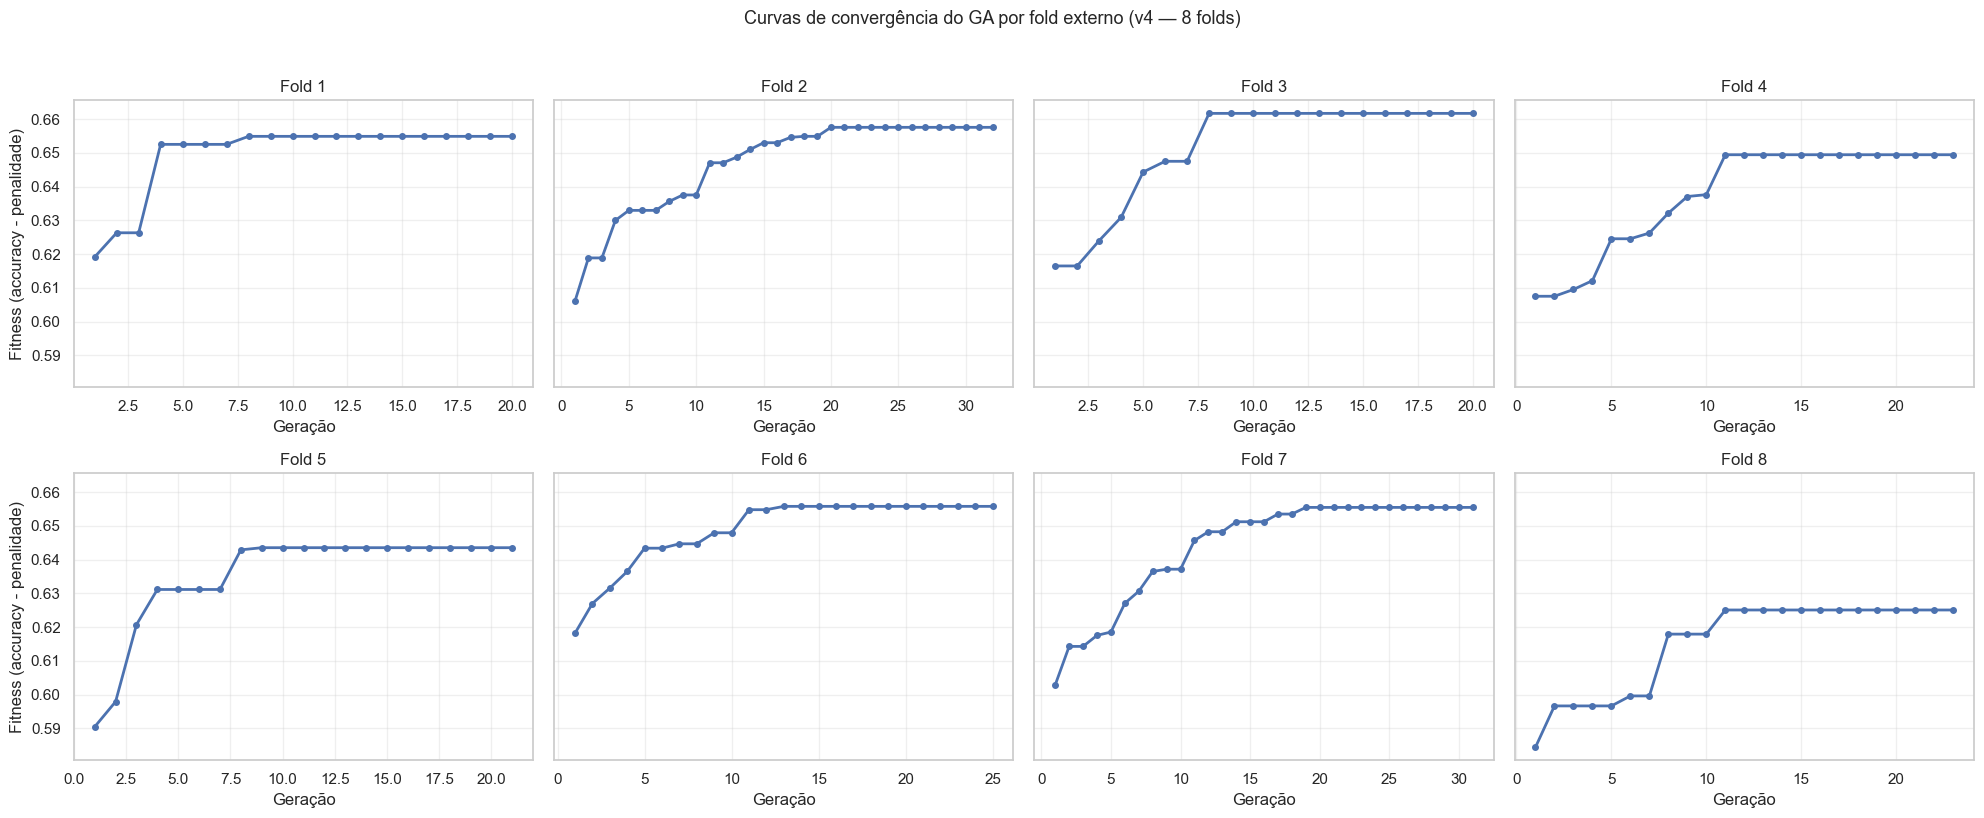

In [15]:
# [v4] 8 folds dispostos em 2 linhas de 4 para melhor visualização
n_folds = len(all_folds_ga_history)
n_cols  = 4
n_rows  = (n_folds + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), sharey=True)
axes_flat = axes.flatten() if n_rows > 1 else axes

for fold_idx, (history, ax) in enumerate(zip(all_folds_ga_history, axes_flat), start=1):
    ax.plot(np.arange(1, len(history) + 1), history, marker="o", linewidth=2, markersize=4)
    ax.set_title(f"Fold {fold_idx}")
    ax.set_xlabel("Geração")
    if fold_idx % n_cols == 1:
        ax.set_ylabel("Fitness (accuracy - penalidade)")  # [v4] era F1-macro
    ax.grid(True, alpha=0.3)

# Oculta subplots vazios se n_folds não for múltiplo de n_cols
for ax in axes_flat[n_folds:]:
    ax.set_visible(False)

fig.suptitle("Curvas de convergência do GA por fold externo (v4 — 8 folds)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 14. Meta-features mais recorrentes nas soluções do GA

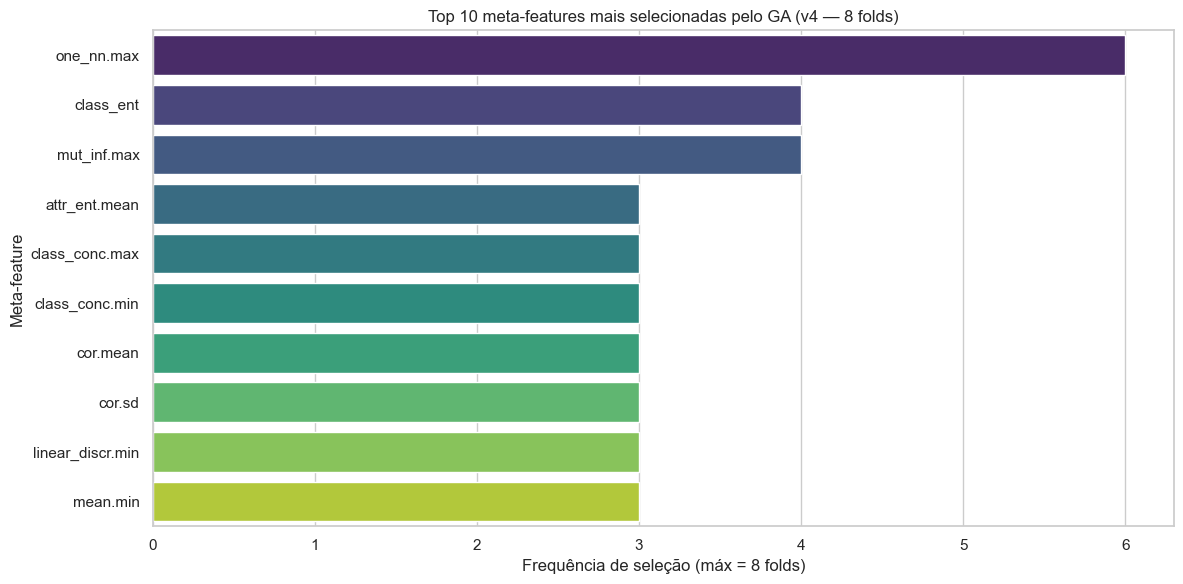

,meta_feature,frequencia
0,one_nn.max,6
1,class_ent,4
2,mut_inf.max,4
3,attr_ent.mean,3
4,class_conc.max,3
5,class_conc.min,3
6,cor.mean,3
7,cor.sd,3
8,linear_discr.min,3
9,mean.min,3


In [16]:
top_features_df = pd.DataFrame(
    selected_feature_counter.most_common(10),
    columns=["meta_feature", "frequencia"],
)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_features_df, x="frequencia", y="meta_feature", palette="viridis")
plt.title("Top 10 meta-features mais selecionadas pelo GA (v4 — 8 folds)")
plt.xlabel("Frequência de seleção (máx = 8 folds)")  # [v4] era máx = 5 folds
plt.ylabel("Meta-feature")
plt.tight_layout()
plt.show()
top_features_df


## 15. Exportação das tabelas para Excel

In [36]:
import openpyxl

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

catalog_df.to_excel(INTERMEDIATE_TABLES_DIR / "01_openml_catalog.xlsx", index=False)
base_results_df.to_excel(INTERMEDIATE_TABLES_DIR / "02_base_level_results.xlsx", index=False)
meta_X.to_excel(INTERMEDIATE_TABLES_DIR / "03_meta_features_matrix.xlsx", index=True)
results_df.to_excel(INTERMEDIATE_TABLES_DIR / "04_outer_cv_results.xlsx", index=False)
summary_table.to_excel(INTERMEDIATE_TABLES_DIR / "05_summary_table.xlsx", index=False)
top_features_df.to_excel(INTERMEDIATE_TABLES_DIR / "06_top_ga_features.xlsx", index=False)
print(f"Tabelas exportadas para: {INTERMEDIATE_TABLES_DIR}")


Tabelas exportadas para: /Users/rafaelribeiro/GitProjects/meta-learning-article/intermidiate_tables_csv


## 16. Gráficos adicionais de análise

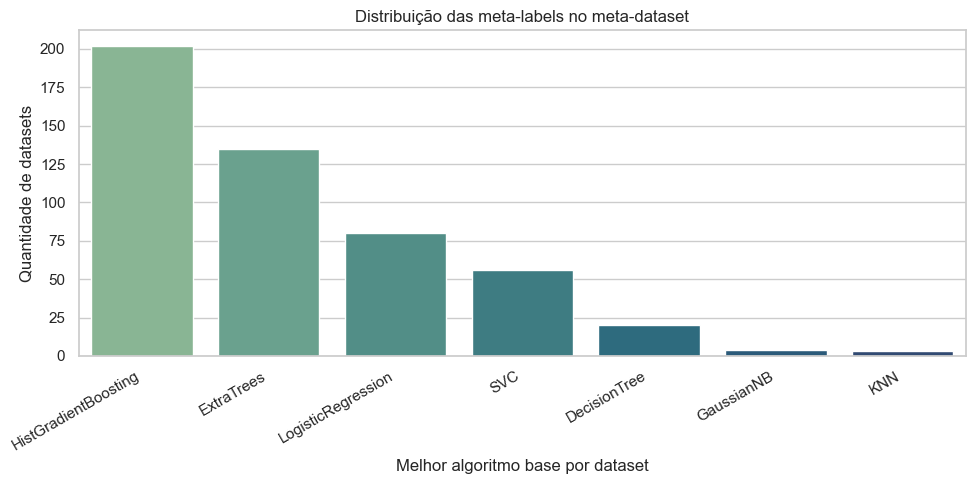

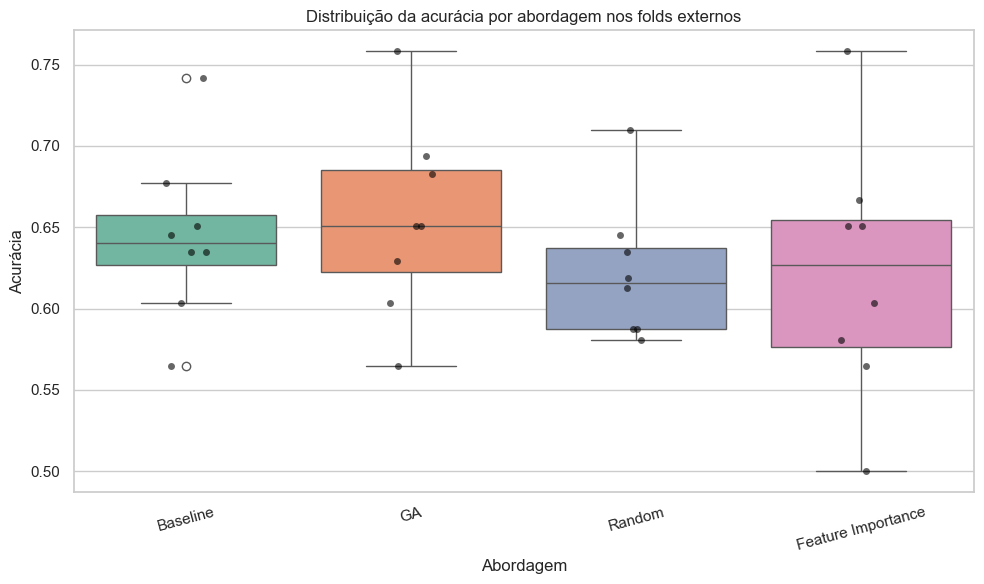

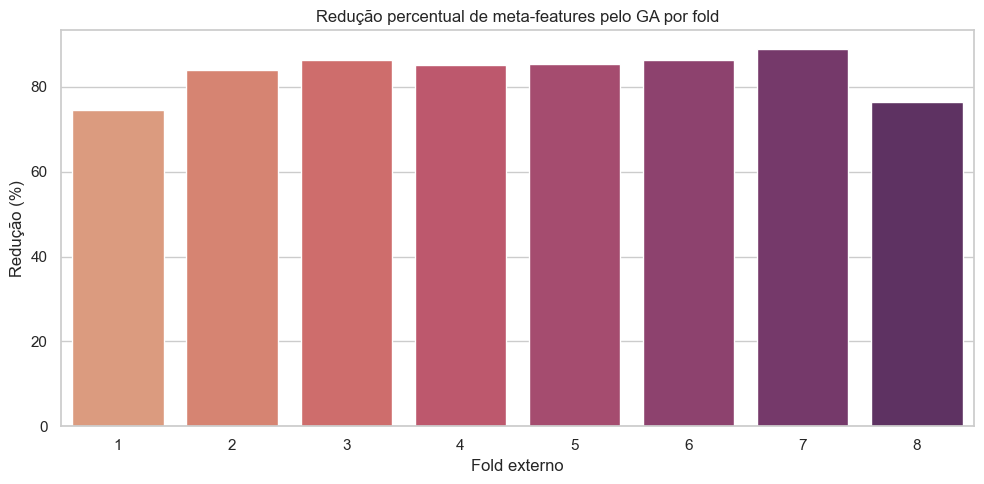

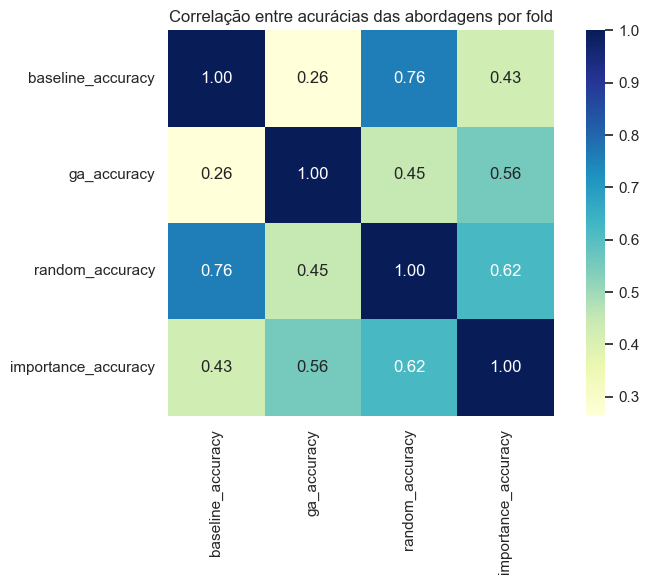

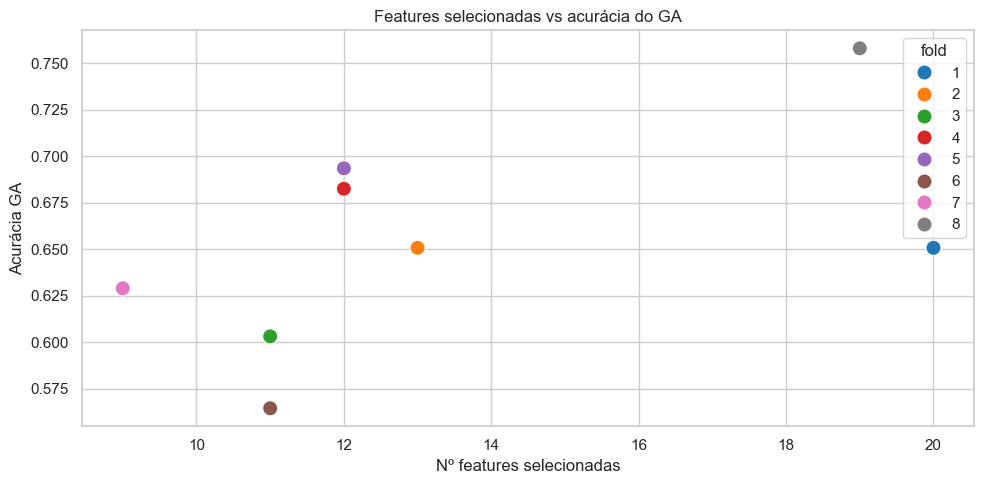

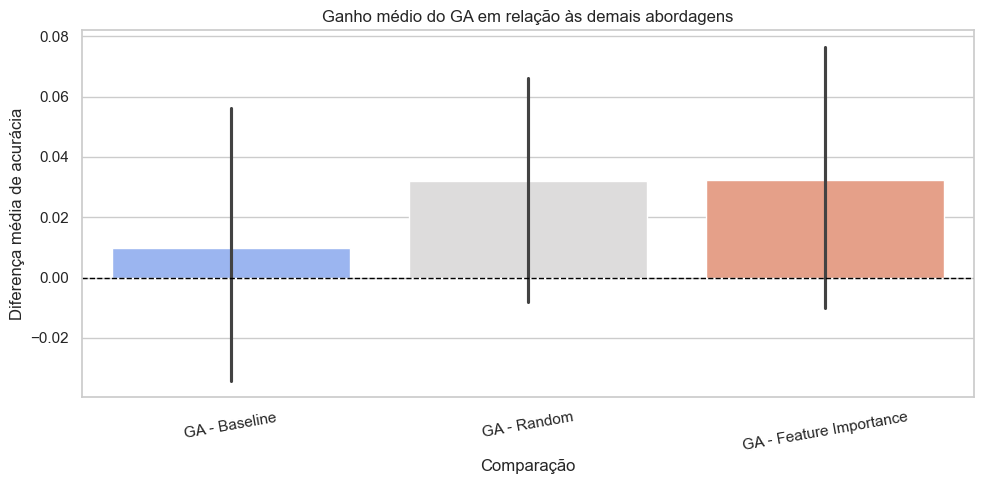

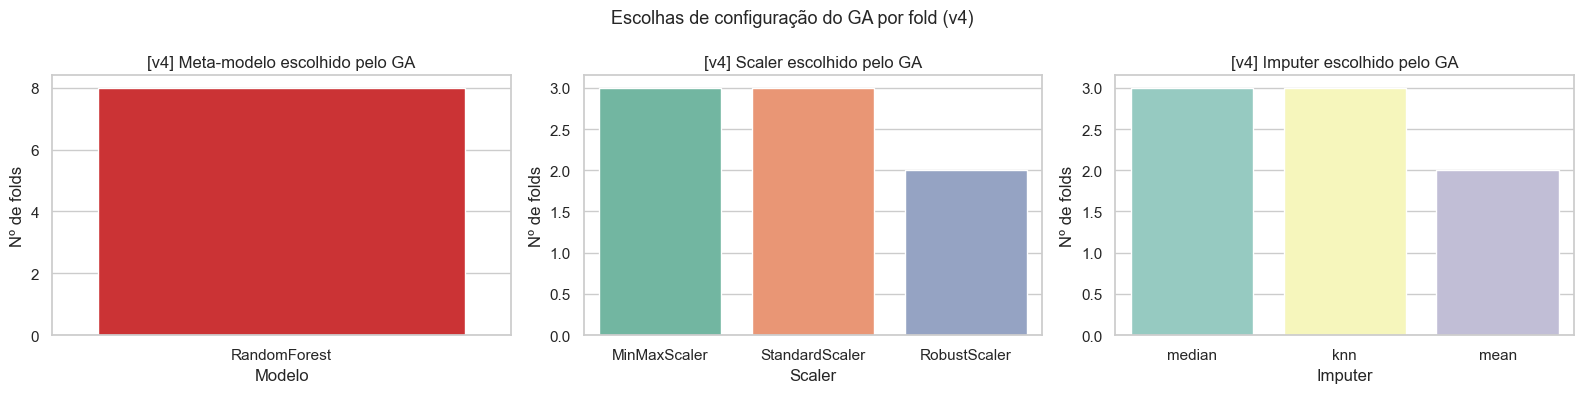

In [17]:
# ── Prepara estruturas auxiliares ─────────────────────────────────────────
meta_label_counts = pd.Series(meta_y).value_counts().reset_index()
meta_label_counts.columns = ["meta_label", "count"]

perf_long = results_df.melt(
    id_vars=["fold"],
    value_vars=["baseline_accuracy","ga_accuracy","random_accuracy","importance_accuracy"],
    var_name="approach", value_name="accuracy",
)
perf_long["approach"] = perf_long["approach"].map({
    "baseline_accuracy": "Baseline", "ga_accuracy": "GA",
    "random_accuracy": "Random", "importance_accuracy": "Feature Importance",
})

results_corr = results_df[[
    "baseline_accuracy","ga_accuracy","random_accuracy","importance_accuracy"
]].corr()

# Distribuição das meta-labels
plt.figure(figsize=(10, 5))
sns.barplot(data=meta_label_counts, x="meta_label", y="count", palette="crest")
plt.title("Distribuição das meta-labels no meta-dataset")
plt.xlabel("Melhor algoritmo base por dataset")
plt.ylabel("Quantidade de datasets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

# Boxplot por abordagem
plt.figure(figsize=(10, 6))
sns.boxplot(data=perf_long, x="approach", y="accuracy", palette="Set2")
sns.stripplot(data=perf_long, x="approach", y="accuracy", color="black", alpha=0.6, size=5)
plt.title("Distribuição da acurácia por abordagem nos folds externos")
plt.xlabel("Abordagem"); plt.ylabel("Acurácia")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

# Redução por fold
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="fold", y="reduction_pct", palette="flare")
plt.title("Redução percentual de meta-features pelo GA por fold")
plt.xlabel("Fold externo"); plt.ylabel("Redução (%)")
plt.tight_layout(); plt.show()

# Correlação entre abordagens
plt.figure(figsize=(8, 6))
sns.heatmap(results_corr, annot=True, cmap="YlGnBu", fmt=".2f", square=True)
plt.title("Correlação entre acurácias das abordagens por fold")
plt.tight_layout(); plt.show()

# Features GA vs acurácia GA
plt.figure(figsize=(10, 5))
sns.scatterplot(data=results_df, x="n_features_ga", y="ga_accuracy",
                hue="fold", palette="tab10", s=120)
plt.title("Features selecionadas vs acurácia do GA")
plt.xlabel("Nº features selecionadas"); plt.ylabel("Acurácia GA")
plt.tight_layout(); plt.show()

# Ganho do GA
gain_df = results_df[["fold","ga_accuracy","baseline_accuracy","random_accuracy","importance_accuracy"]].copy()
gain_df["GA - Baseline"]           = gain_df["ga_accuracy"] - gain_df["baseline_accuracy"]
gain_df["GA - Random"]             = gain_df["ga_accuracy"] - gain_df["random_accuracy"]
gain_df["GA - Feature Importance"] = gain_df["ga_accuracy"] - gain_df["importance_accuracy"]
gain_long = gain_df[["fold","GA - Baseline","GA - Random","GA - Feature Importance"]].melt(
    id_vars="fold", var_name="comparison", value_name="gain"
)
plt.figure(figsize=(10, 5))
sns.barplot(data=gain_long, x="comparison", y="gain", palette="coolwarm")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Ganho médio do GA em relação às demais abordagens")
plt.xlabel("Comparação"); plt.ylabel("Diferença média de acurácia")
plt.xticks(rotation=10); plt.tight_layout(); plt.show()

# ── [v4] Distribuição dos meta-modelos e pré-procs escolhidos pelo GA ─────
# Visualiza se o GA prefere um modelo específico ou diversifica por fold.
if "ga_model" in results_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Modelo
    model_counts = results_df["ga_model"].value_counts().reset_index()
    model_counts.columns = ["Modelo", "Folds"]
    sns.barplot(data=model_counts, x="Modelo", y="Folds", palette="Set1", ax=axes[0])
    axes[0].set_title("[v4] Meta-modelo escolhido pelo GA")
    axes[0].set_ylabel("Nº de folds")

    # Scaler
    scaler_counts = results_df["ga_scaler"].value_counts().reset_index()
    scaler_counts.columns = ["Scaler", "Folds"]
    sns.barplot(data=scaler_counts, x="Scaler", y="Folds", palette="Set2", ax=axes[1])
    axes[1].set_title("[v4] Scaler escolhido pelo GA")
    axes[1].set_ylabel("Nº de folds")

    # Imputer
    imputer_counts = results_df["ga_imputer"].value_counts().reset_index()
    imputer_counts.columns = ["Imputer", "Folds"]
    sns.barplot(data=imputer_counts, x="Imputer", y="Folds", palette="Set3", ax=axes[2])
    axes[2].set_title("[v4] Imputer escolhido pelo GA")
    axes[2].set_ylabel("Nº de folds")

    plt.suptitle("Escolhas de configuração do GA por fold (v4)", fontsize=13)
    plt.tight_layout()
    plt.show()


## 17. Análise interpretativa dos resultados

### Análise 1 — Comparação geral entre as abordagens

Compara a acurácia média ± desvio padrão das 4 estratégias.
Se o GA superar ou empatar com o Baseline usando menos features,
há um bom trade-off acurácia/dimensionalidade.


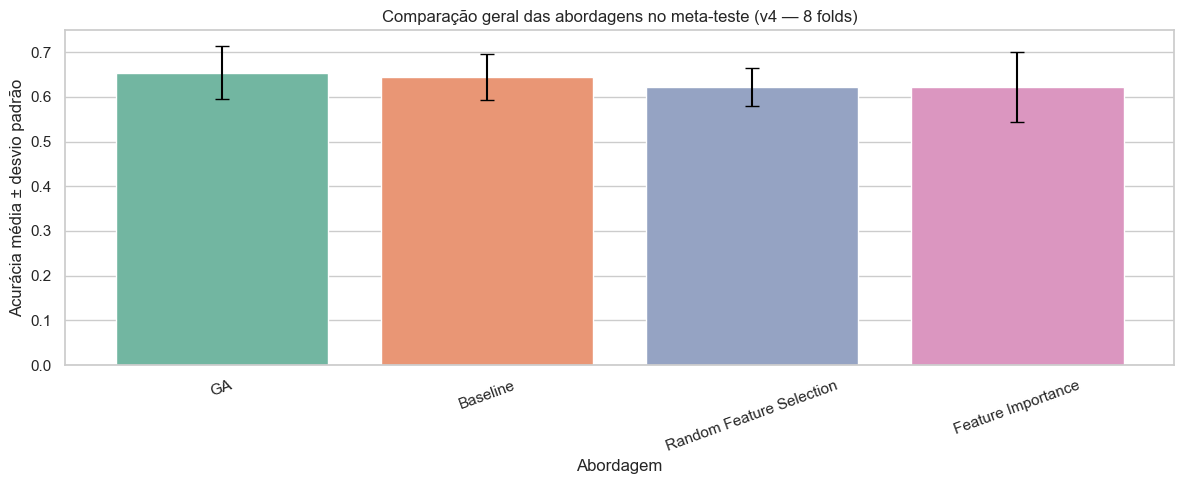

,Abordagem,Acurácia média no meta-teste,Desvio padrão
0,GA,0.654058,0.059091
1,Baseline,0.644105,0.051968
2,Random Feature Selection,0.622120,0.042427
3,Feature Importance,0.621832,0.077846


In [19]:
# Análise 1 — Comparação geral entre abordagens + Ensemble Pareto [v4]
# [v4] Inclui o ensemble no barplot se os resultados estiverem disponíveis.

plt.figure(figsize=(12, 5))
plot_df = summary_table.copy()

# Tenta incluir ensemble se disponível
if ENSEMBLE_PATH.exists():
    ens_result = load_pickle(ENSEMBLE_PATH)
    ens_acc    = ens_result["ensemble_accuracy"]
    ensemble_row = pd.DataFrame([{
        "Abordagem": "Ensemble Pareto [v4]",
        "Acurácia média no meta-teste": ens_acc,
        "Desvio padrão": 0.0,
    }])
    plot_df = pd.concat([plot_df, ensemble_row], ignore_index=True)
    print(f"[v4] Ensemble Pareto acurácia global: {ens_acc:.4f}")

sns.barplot(data=plot_df, x="Abordagem", y="Acurácia média no meta-teste", palette="Set2")
plt.errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["Acurácia média no meta-teste"],
    yerr=plot_df["Desvio padrão"],
    fmt="none", ecolor="black", capsize=5,
)
plt.title("Comparação geral das abordagens no meta-teste (v4 — 8 folds)")
plt.xlabel("Abordagem"); plt.ylabel("Acurácia média ± desvio padrão")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()
display(summary_table)


### Análise 2 — Redução de dimensionalidade pelo GA

GA reduziu em média 63.67% das meta-features, mantendo 29.20 de 80.40 (51.20 removidas por fold).


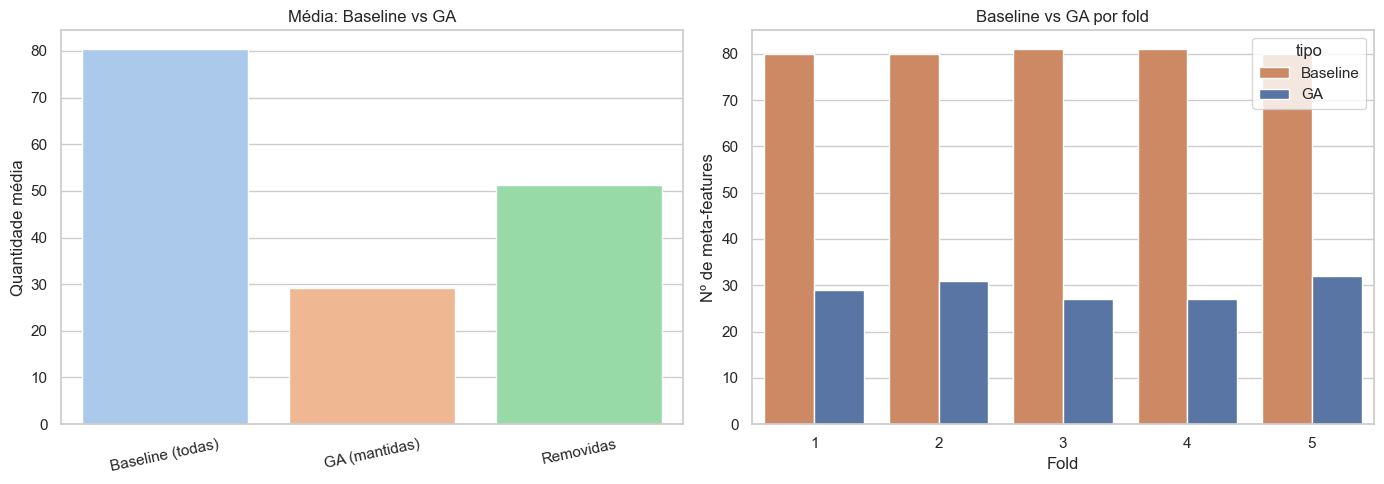

,fold,n_features_total,n_features_ga,reduction_pct
0,1,80,29,63.750000
1,2,80,31,61.250000
2,3,81,27,66.666667
3,4,81,27,66.666667
4,5,80,32,60.000000


In [39]:
avg_total   = results_df["n_features_total"].mean()
avg_ga      = results_df["n_features_ga"].mean()
avg_red     = results_df["reduction_pct"].mean()
avg_removed = avg_total - avg_ga
print(f"GA reduziu em média {avg_red:.2f}% das meta-features, "
      f"mantendo {avg_ga:.2f} de {avg_total:.2f} ({avg_removed:.2f} removidas por fold).")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=pd.DataFrame({
        "categoria": ["Baseline (todas)", "GA (mantidas)", "Removidas"],
        "quantidade": [avg_total, avg_ga, avg_removed],
    }),
    x="categoria", y="quantidade", palette="pastel", ax=axes[0],
)
axes[0].set_title("Média: Baseline vs GA")
axes[0].set_xlabel(""); axes[0].set_ylabel("Quantidade média")
axes[0].tick_params(axis="x", rotation=12)

comp_by_fold = pd.DataFrame({
    "fold":    results_df["fold"].tolist() * 2,
    "tipo":    ["Baseline"]*len(results_df) + ["GA"]*len(results_df),
    "n_feats": results_df["n_features_total"].tolist() + results_df["n_features_ga"].tolist(),
})
sns.barplot(data=comp_by_fold, x="fold", y="n_feats", hue="tipo",
            palette=["#DD8452","#4C72B0"], ax=axes[1])
axes[1].set_title("Baseline vs GA por fold (v4 — 8 folds)")
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Nº de meta-features")
plt.tight_layout(); plt.show()
display(results_df[["fold","n_features_total","n_features_ga","reduction_pct","ga_model","ga_scaler"]])


### Análise 3 — Estabilidade do GA entre os folds

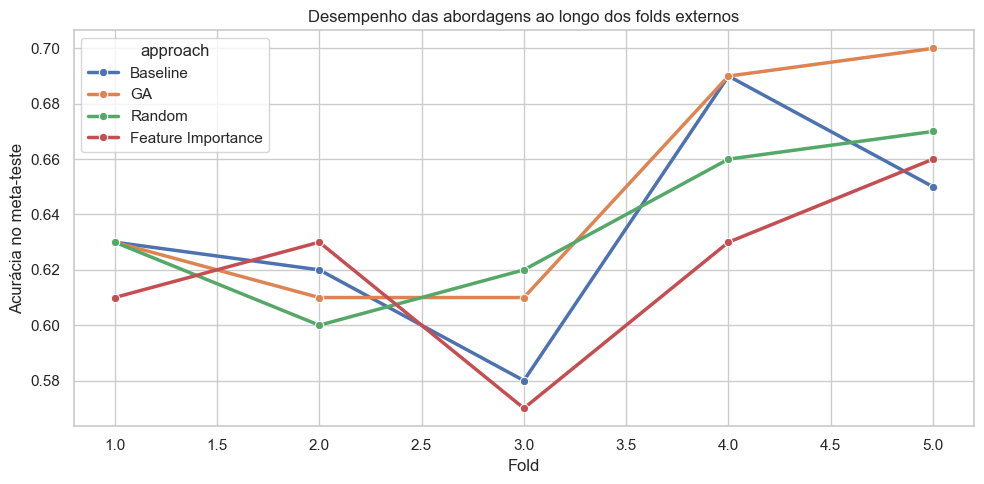

,fold,baseline_accuracy,ga_accuracy,random_accuracy,importance_accuracy
0,1,0.63,0.63,0.63,0.61
1,2,0.62,0.61,0.60,0.63
2,3,0.58,0.61,0.62,0.57
3,4,0.69,0.69,0.66,0.63
4,5,0.65,0.70,0.67,0.66


In [40]:
comp_fold = results_df[["fold","baseline_accuracy","ga_accuracy",
                        "random_accuracy","importance_accuracy"]].melt(
    id_vars="fold", var_name="approach", value_name="accuracy"
)
comp_fold["approach"] = comp_fold["approach"].map({
    "baseline_accuracy":"Baseline","ga_accuracy":"GA",
    "random_accuracy":"Random","importance_accuracy":"Feature Importance",
})
plt.figure(figsize=(10, 5))
sns.lineplot(data=comp_fold, x="fold", y="accuracy", hue="approach", marker="o", linewidth=2.5)
plt.title("Desempenho das abordagens ao longo dos 8 folds externos (v4)")
plt.xlabel("Fold"); plt.ylabel("Acurácia no meta-teste")
plt.tight_layout(); plt.show()
display(results_df[["fold","baseline_accuracy","ga_accuracy","random_accuracy","importance_accuracy"]])


### Análise 4 — Ganho do GA em relação às alternativas

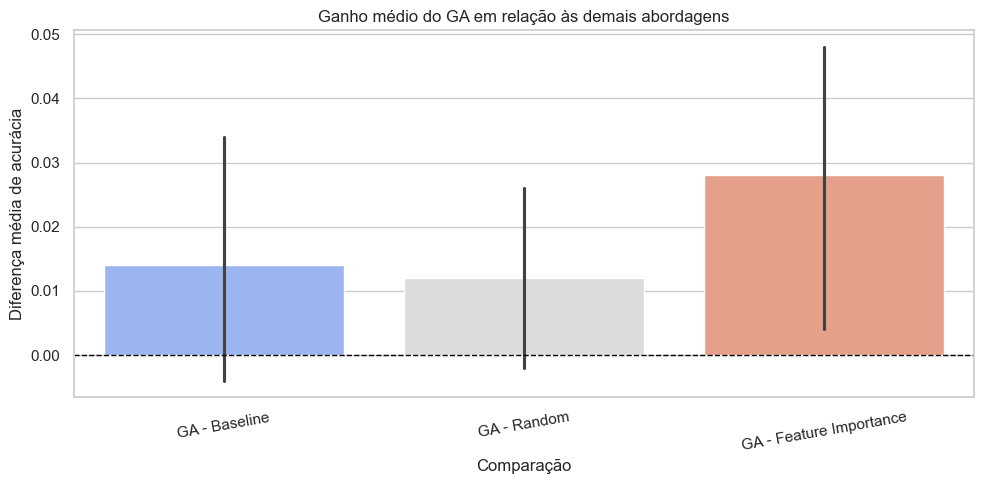

,comparison,gain
0,GA - Baseline,0.014
1,GA - Feature Importance,0.028
2,GA - Random,0.012


In [41]:
gain_df = results_df[["fold","ga_accuracy","baseline_accuracy",
                       "random_accuracy","importance_accuracy"]].copy()
gain_df["GA - Baseline"]           = gain_df["ga_accuracy"] - gain_df["baseline_accuracy"]
gain_df["GA - Random"]             = gain_df["ga_accuracy"] - gain_df["random_accuracy"]
gain_df["GA - Feature Importance"] = gain_df["ga_accuracy"] - gain_df["importance_accuracy"]
gain_long = gain_df[["fold","GA - Baseline","GA - Random","GA - Feature Importance"]].melt(
    id_vars="fold", var_name="comparison", value_name="gain"
)
plt.figure(figsize=(10, 5))
sns.barplot(data=gain_long, x="comparison", y="gain", palette="coolwarm")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Ganho médio do GA em relação às demais abordagens (v4 — 8 folds)")
plt.xlabel("Comparação"); plt.ylabel("Diferença média de acurácia")
plt.xticks(rotation=10); plt.tight_layout(); plt.show()
display(gain_long.groupby("comparison", as_index=False)["gain"].mean())


### Análise 5 — Distribuição das meta-labels

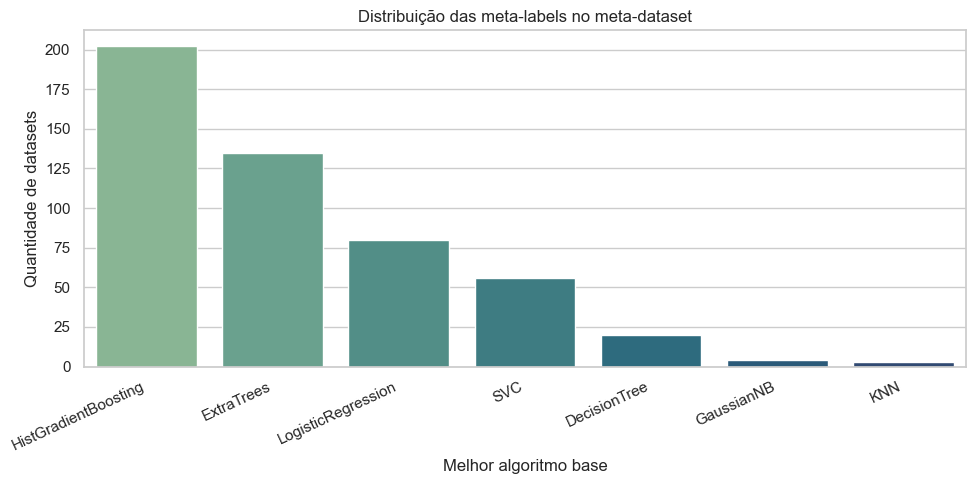

,meta_label,count
0,HistGradientBoosting,202
1,ExtraTrees,135
2,LogisticRegression,80
3,SVC,56
4,DecisionTree,20
5,GaussianNB,4
6,KNN,3


In [42]:
dist = pd.Series(meta_y).value_counts().reset_index()
dist.columns = ["meta_label", "count"]
plt.figure(figsize=(10, 5))
sns.barplot(data=dist, x="meta_label", y="count", palette="crest")
plt.title("Distribuição das meta-labels no meta-dataset")
plt.xlabel("Melhor algoritmo base"); plt.ylabel("Quantidade de datasets")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()
display(dist)


### Análise 6 — Meta-features preferidas pelo GA

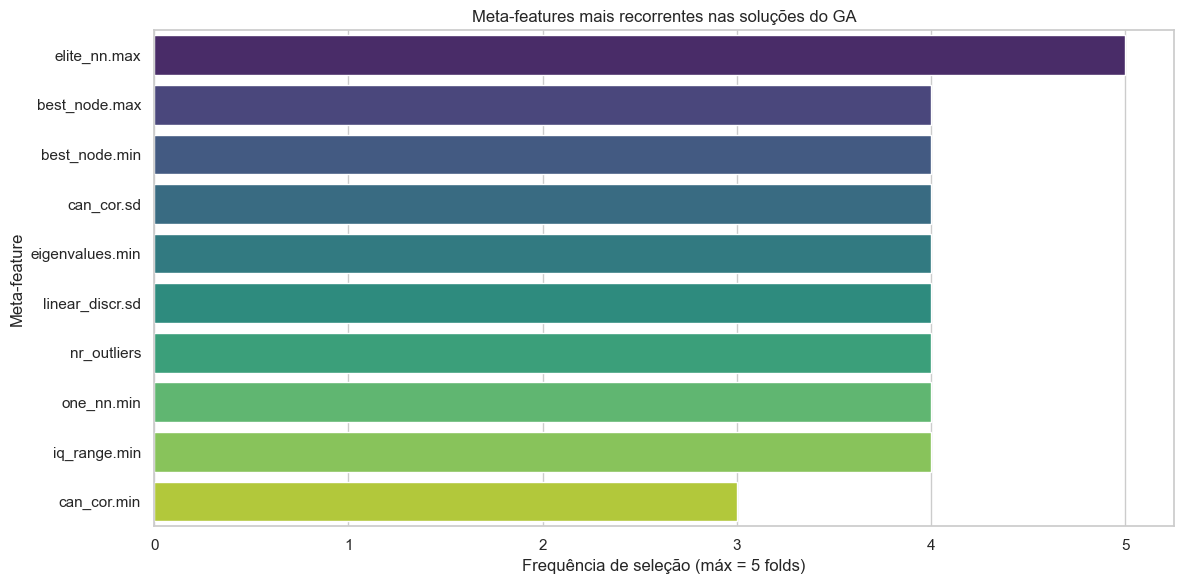

,meta_feature,frequencia
0,elite_nn.max,5
1,best_node.max,4
2,best_node.min,4
3,can_cor.sd,4
4,eigenvalues.min,4
5,linear_discr.sd,4
6,nr_outliers,4
7,one_nn.min,4
8,iq_range.min,4
9,can_cor.min,3


In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_features_df, x="frequencia", y="meta_feature", palette="viridis")
plt.title("Meta-features mais recorrentes nas soluções do GA (v4 — 8 folds)")
plt.xlabel("Frequência de seleção (máx = 8 folds)"); plt.ylabel("Meta-feature")
plt.tight_layout(); plt.show()
display(top_features_df)


### Análise 7 — Ensemble Pareto pós-GA [v4]

As melhores soluções de cada fold formam um ensemble votado. A classe predita para cada dataset é determinada por maioria simples entre os votos dos folds que o tiveram no conjunto de teste.

In [ ]:
# ── [v4] Análise 7 — Ensemble Pareto: comparação por dataset ─────────────
# Exibe a acurácia global do ensemble vs melhor GA individual e baseline.
# O ensemble aproveita a diversidade dos 8 folds para superar soluções
# individuais — análogo ao bagging mas entre folds de cross-validation.

if ENSEMBLE_PATH.exists():
    ens_result = load_pickle(ENSEMBLE_PATH)
    print("=== Resultados do Ensemble Pareto [v4] ===")
    print(f"  Datasets cobertos:          {ens_result['n_datasets_covered']}")
    print(f"  Acurácia global (ensemble): {ens_result['ensemble_accuracy']:.4f}")
    print(f"  Acurácia média GA (por fold): {ens_result['ga_accuracy_mean']:.4f}")
    delta = ens_result['ensemble_accuracy'] - ens_result['ga_accuracy_mean']
    print(f"  Ganho ensemble vs GA médio: {delta:+.4f}")

    # Barplot de comparação
    comp_ens = pd.DataFrame({
        "Estratégia": ["GA médio (8 folds)", "Ensemble Pareto [v4]",
                       "Baseline médio"],
        "Acurácia": [
            ens_result["ga_accuracy_mean"],
            ens_result["ensemble_accuracy"],
            results_df["baseline_accuracy"].mean(),
        ]
    })
    plt.figure(figsize=(8, 4))
    bars = sns.barplot(data=comp_ens, x="Estratégia", y="Acurácia", palette="muted")
    plt.title("Ensemble Pareto vs estratégias individuais (v4)")
    plt.ylabel("Acurácia"); plt.xticks(rotation=10)
    plt.ylim(0, 1); plt.tight_layout(); plt.show()
else:
    print("Ensemble Pareto não disponível — execute o loop de treinamento completo.")
